In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler
from scipy.special import expit  # Sigmoid function
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_regression, VarianceThreshold
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

In [2]:
# Set plotting style for better visuals
sns.set_palette("husl")

# Load the dataset from a CSV file
data = pd.read_csv('bursary.csv')

# Rename columns for precision and consistency
data = data.rename(columns={
    "Year of Course Completion": "exp_completion", 
    "Year of Application": "app_year",
    "Amount Applied (Kshs)": "amt_applied",
    "Fee Balance": "fee_balance",
    "Family status.": "family_status",
    "Care of": "caregiver",
    "Employment Type": "emp_type",
    "Past Financial Support(NG-CDF)": "past_ngcdf",
    "Past Financial Support(Others)": "other_support",
    "If yes, specify how much.": "support_amt",
    "Individual Disability Status": "ind_disability",
    "Parent/Guardian Disability Status": "pg_disability",
    "Supportive documents Available": "docs_available",
    "Recommendation": "recommendation",
    "Academic Level": "acad_level",
    "Mode of Study": "study_mode",
    "Average Academic Performance": "acad_perf",
    "Course Duration": "course_dur"
})

# Drop unnecessary columns
columns_to_drop = [
    "Student's Name", 
    "Gender", 
    "Ward", 
    "Name of the school(Secondary/Tertiary/University)", 
    "Course of Study", 
    "Is it a main Source of Income()", 
    "Last Received"
]
data = data.drop(columns=columns_to_drop, errors='ignore')

# Display the first few rows
data.head()

,Name,app_year,acad_level,acad_perf,School,course_dur,study_mode,exp_completion,amt_applied,fee_balance,family_status,caregiver,emp_type,past_ngcdf,other_support,support_amt,ind_disability,pg_disability,docs_available,recommendation
0,Anne Kwamboka Omwamba,2021,Secondary School,Good,Great Mercy,4,Day scholar,2022,10000,10000,Both Parents,All Parents,NaN,No,No,0,No,No,Yes,Approve
1,Wafula Violet Nanjala,2021,Secondary School,Excellent,St Josephs Girls High School,4,Bording,2025,40000,40000,Both Parents,All Parents,Retired,No,No,0,No,No,Partial,Approve
2,John Kibet Watua,2021,Secondary School,Good,St Michael Top Station,4,Bording,2024,12000,12000,Both Parents,All Parents,NaN,No,No,0,No,No,Partial,Approve
3,Ronny Sang Maru,2021,Secondary School,Fair,Maziwa Secondary School,4,Day scholar,2021,3000,3000,Both Parents,All Parents,Casual,No,No,0,No,No,Yes,Approve
4,Anne Wanjiku Maina,2021,Secondary School,Good,Butere Girls,4,Bording,2022,20000,45000,Both Parents,All Parents,Self Employed,No,No,0,No,No,Partial,Approve


In [3]:
data.columns

Index(['Name', 'app_year', 'acad_level', 'acad_perf', 'School', 'course_dur',
       'study_mode', 'exp_completion', 'amt_applied', 'fee_balance',
       'family_status', 'caregiver', 'emp_type', 'past_ngcdf', 'other_support',
       'support_amt', 'ind_disability', 'pg_disability', 'docs_available',
       'recommendation'],
      dtype='object')

=== Data Shape ===
Rows: 6021, Columns: 20

=== Data Types ===
Name               object
app_year            int64
acad_level         object
acad_perf          object
School             object
course_dur          int64
study_mode         object
exp_completion      int64
amt_applied       float64
fee_balance       float64
family_status      object
caregiver          object
emp_type           object
past_ngcdf         object
other_support      object
support_amt         int64
ind_disability     object
pg_disability      object
docs_available     object
recommendation     object
dtype: object

=== Missing Values ===
Series([], dtype: int64)

=== Numerical Columns Summary ===
        amt_applied   fee_balance   support_amt
count   6021.000000   6021.000000   6021.000000
mean   17354.877512  17319.545840    714.499253
std    14518.244300  14393.755532   2549.368504
min     1000.000000   1000.000000      0.000000
25%     9000.000000   9000.000000      0.000000
50%    10000.000000  10000.0000

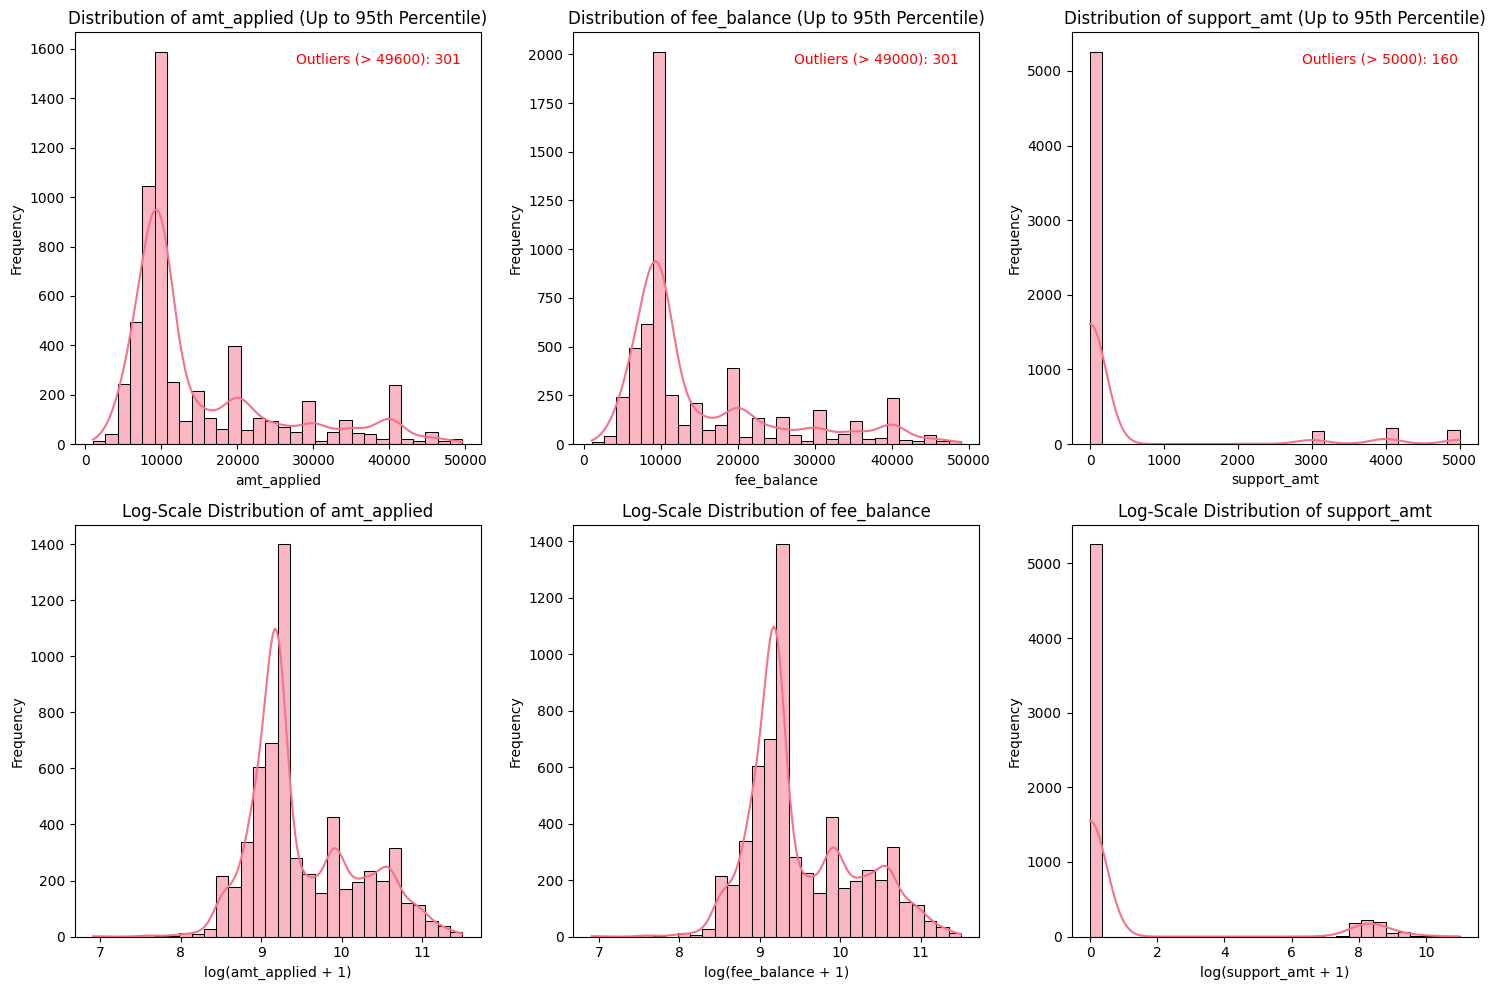

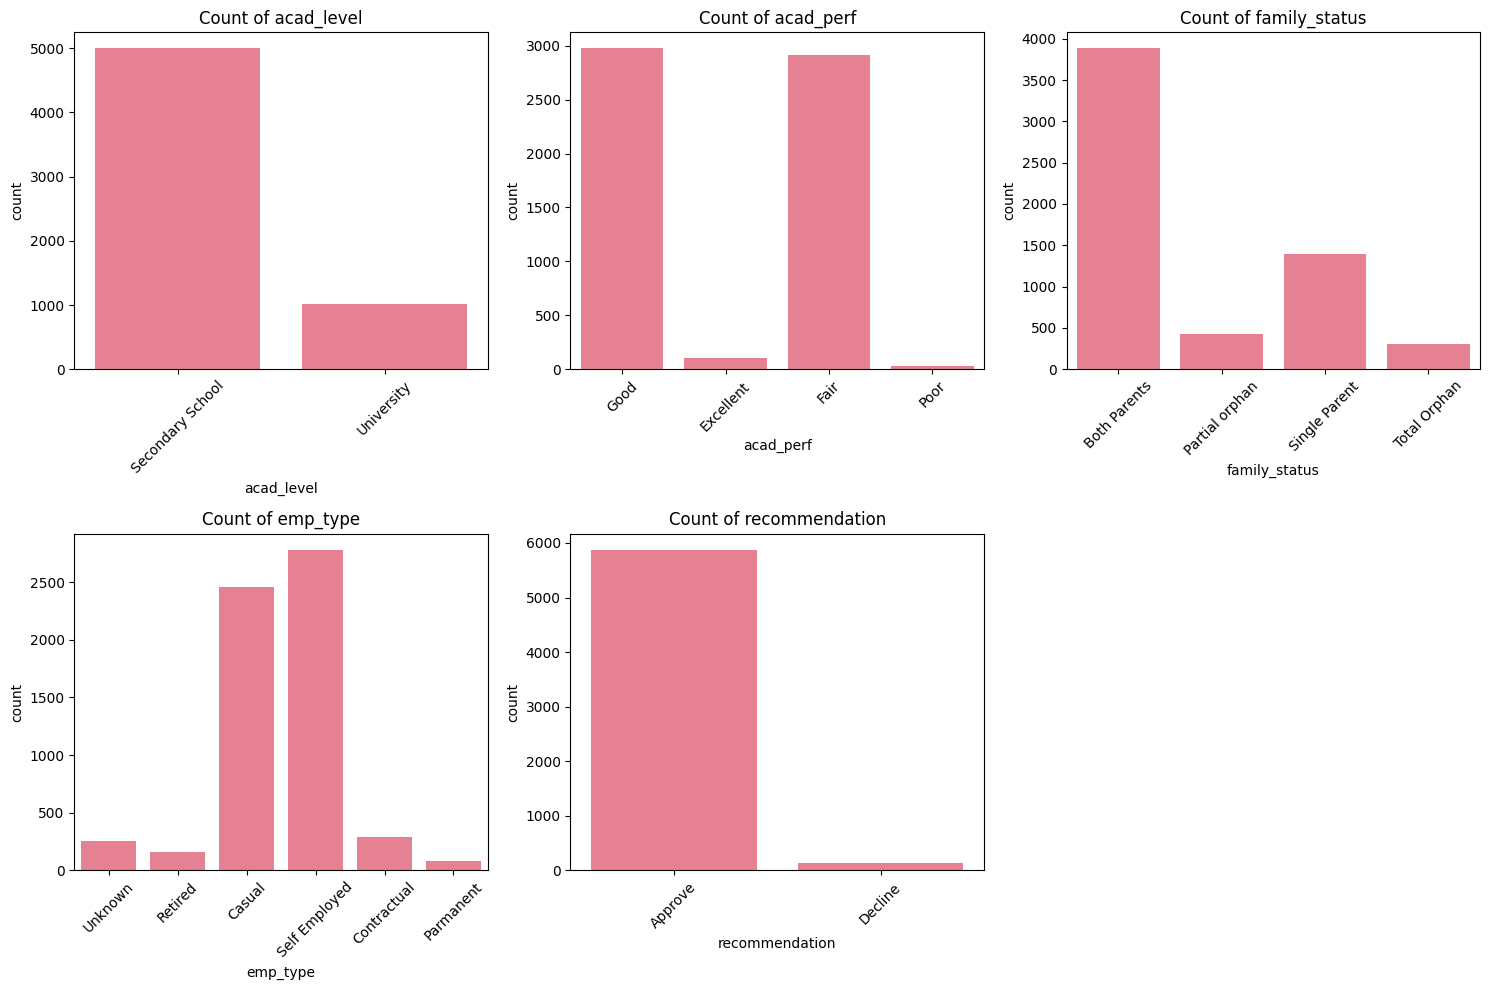

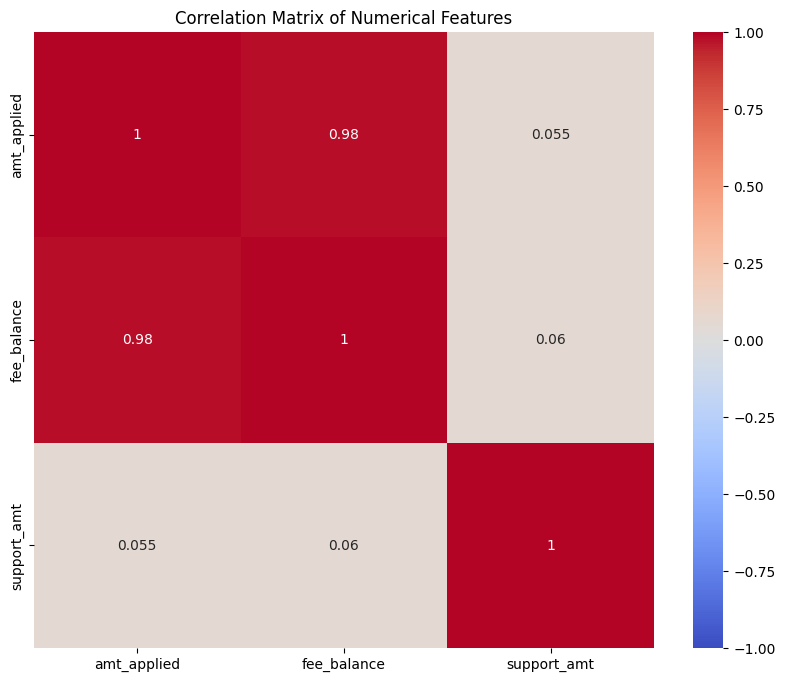

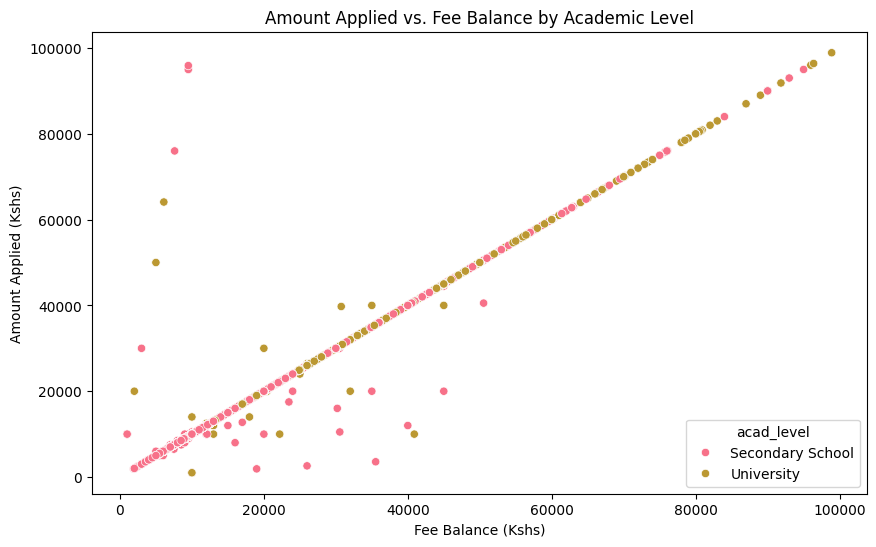

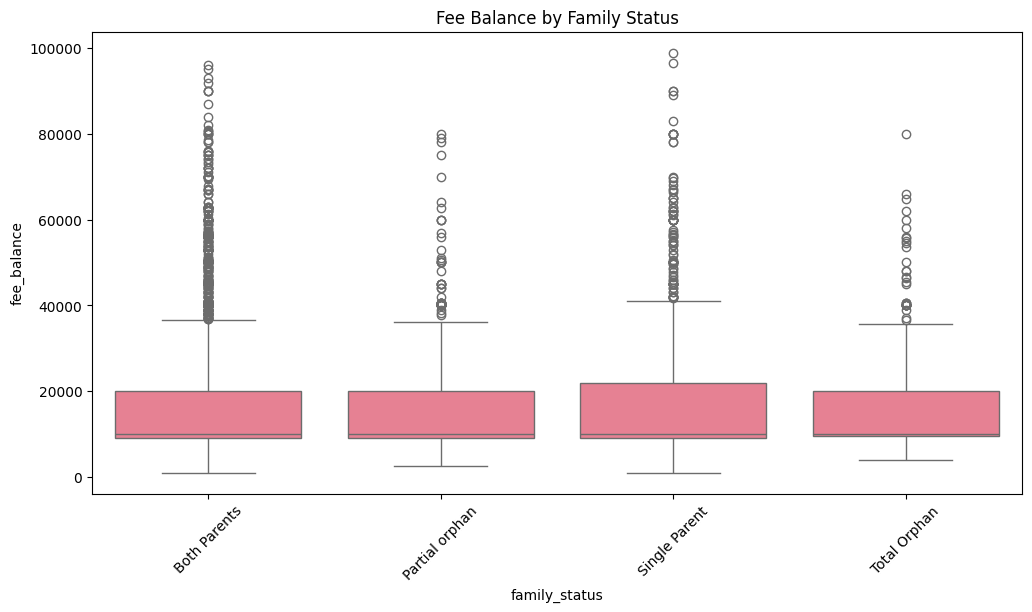

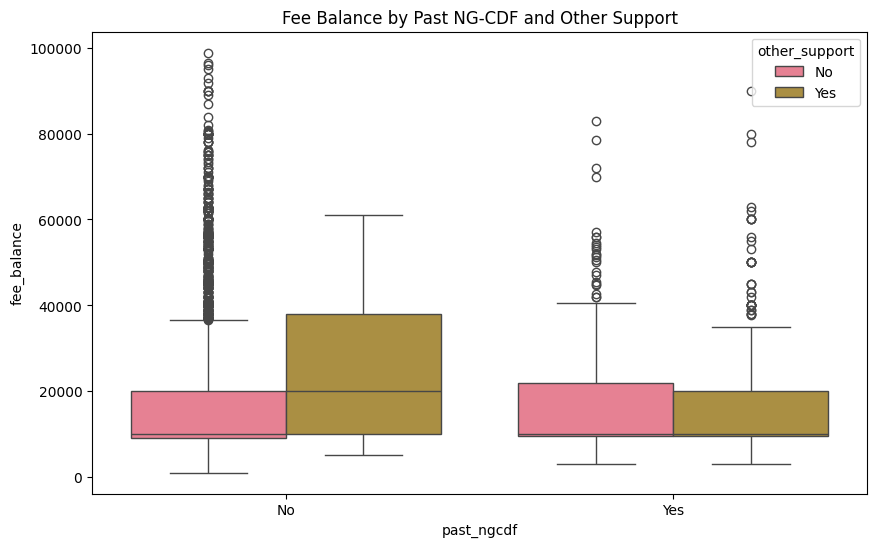

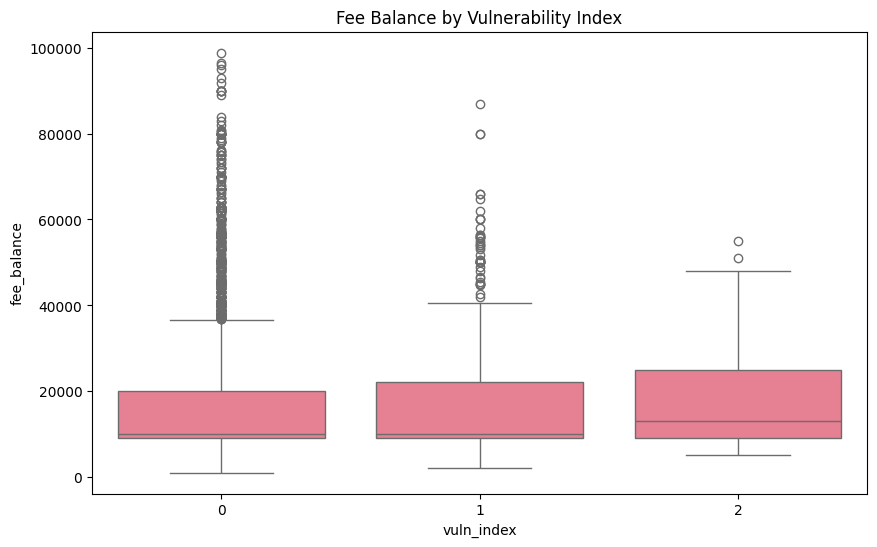

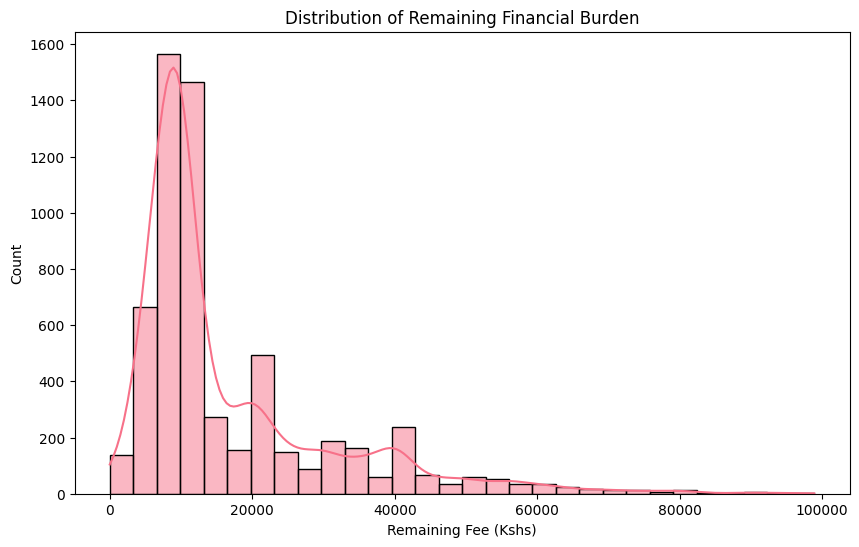


Chi-Square (Recommendation vs. Academic Performance): chi2 = 51.70, p-value = 0.0000

=== Key EDA Insights ===
1. Missing Values: 0 total across 0 columns.
2. Median Fee Balance: 10000 Kshs.
3. Most Common Family Status: Both Parents
4. Approval Rate: 97.64%
5. Outliers in Fee Balance: 301 above 95th percentile.


In [4]:
# Convert numerical columns to float and handle missing values early
numerical_cols = ['amt_applied', 'fee_balance', 'support_amt']
for col in numerical_cols:
    data[col] = pd.to_numeric(data[col].astype(str).str.replace(',', ''), errors='coerce')
    data[col].fillna(data[col].median(), inplace=True)  # Impute NaNs with median

# Fix typos and handle missing values in categorical columns
data['study_mode'] = data['study_mode'].replace('Bording', 'Boarding')  # Fix typo
data['study_mode'].fillna(data['study_mode'].mode()[0], inplace=True)  # Impute with mode
data['emp_type'].fillna('Unknown', inplace=True)  # Impute with 'Unknown'

# --- 1. Basic Data Overview ---
print("=== Data Shape ===")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

print("\n=== Data Types ===")
print(data.dtypes)

print("\n=== Missing Values ===")
missing = data.isnull().sum()
print(missing[missing > 0])  # Show only columns with missing values

# --- 2. Summary Statistics ---
print("\n=== Numerical Columns Summary ===")
print(data[numerical_cols].describe())

print("\n=== Categorical Columns Summary ===")
categorical_cols = ['acad_level', 'acad_perf', 'study_mode', 'family_status', 'caregiver', 
                    'emp_type', 'past_ngcdf', 'other_support', 'ind_disability', 
                    'pg_disability', 'docs_available', 'recommendation']
for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(data[col].value_counts(dropna=False))

# --- 3. Distribution Analysis ---
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    # Original distribution (capped at 95th percentile for visualization)
    plt.subplot(2, 3, i)
    cap_value = data[col].quantile(0.95)
    filtered_data = data[col][data[col] <= cap_value]
    sns.histplot(filtered_data, kde=True, bins=30)
    plt.title(f'Distribution of {col} (Up to 95th Percentile)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    outlier_count = len(data[col][data[col] > cap_value])
    plt.text(0.95, 0.95, f'Outliers (> {cap_value:.0f}): {outlier_count}', 
             transform=plt.gca().transAxes, ha='right', va='top', fontsize=10, color='red')

    # Log-scale histogram
    plt.subplot(2, 3, i + 3)
    log_data = np.log1p(data[col])
    sns.histplot(log_data, kde=True, bins=30)
    plt.title(f'Log-Scale Distribution of {col}')
    plt.xlabel(f'log({col} + 1)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- 4. Categorical Variable Analysis ---
key_cats = ['acad_level', 'acad_perf', 'family_status', 'emp_type', 'recommendation']
plt.figure(figsize=(15, 10))
for i, col in enumerate(key_cats, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=data, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 5. Relationships and Correlations ---
plt.figure(figsize=(10, 8))
corr_matrix = data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Amount Applied vs. Fee Balance by Academic Level
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='fee_balance', y='amt_applied', hue='acad_level')
plt.title('Amount Applied vs. Fee Balance by Academic Level')
plt.xlabel('Fee Balance (Kshs)')
plt.ylabel('Amount Applied (Kshs)')
plt.show()

# --- 6. Financial Need Analysis ---
# Fee Balance vs. Family Status
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='family_status', y='fee_balance')
plt.title('Fee Balance by Family Status')
plt.xticks(rotation=45)
plt.show()

# Past Support Impact
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='past_ngcdf', y='fee_balance', hue='other_support')
plt.title('Fee Balance by Past NG-CDF and Other Support')
plt.show()

# --- 7. Custom Insights for ML Model ---
# Vulnerability Index
data['vuln_index'] = (data['ind_disability'] == 'Yes').astype(int) + \
                     (data['pg_disability'].isin(['Yes', 'Chronic Disease'])).astype(int) + \
                     (data['family_status'].isin(['Partial Orphan', 'Total Orphan'])).astype(int)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='vuln_index', y='fee_balance')
plt.title('Fee Balance by Vulnerability Index')
plt.show()

# Remaining Financial Burden
data['remaining_fee'] = data['fee_balance'] - data['support_amt']
data['remaining_fee'] = data['remaining_fee'].clip(lower=0)  # Set negative values to 0
plt.figure(figsize=(10, 6))
sns.histplot(data['remaining_fee'], bins=30, kde=True)
plt.title('Distribution of Remaining Financial Burden')
plt.xlabel('Remaining Fee (Kshs)')
plt.show()

# --- 8. Statistical Tests ---
# Chi-Square: Recommendation vs. Academic Performance
contingency_table = pd.crosstab(data['recommendation'], data['acad_perf'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square (Recommendation vs. Academic Performance): chi2 = {chi2:.2f}, p-value = {p:.4f}")

# --- 9. Summary Report ---
print("\n=== Key EDA Insights ===")
print(f"1. Missing Values: {missing.sum()} total across {len(missing[missing > 0])} columns.")
print(f"2. Median Fee Balance: {data['fee_balance'].median():.0f} Kshs.")
print(f"3. Most Common Family Status: {data['family_status'].mode()[0]}")
print(f"4. Approval Rate: {data['recommendation'].value_counts(normalize=True).get('Approve', 0):.2%}")
print(f"5. Outliers in Fee Balance: {len(data[data['fee_balance'] > data['fee_balance'].quantile(0.95)])} above 95th percentile.")


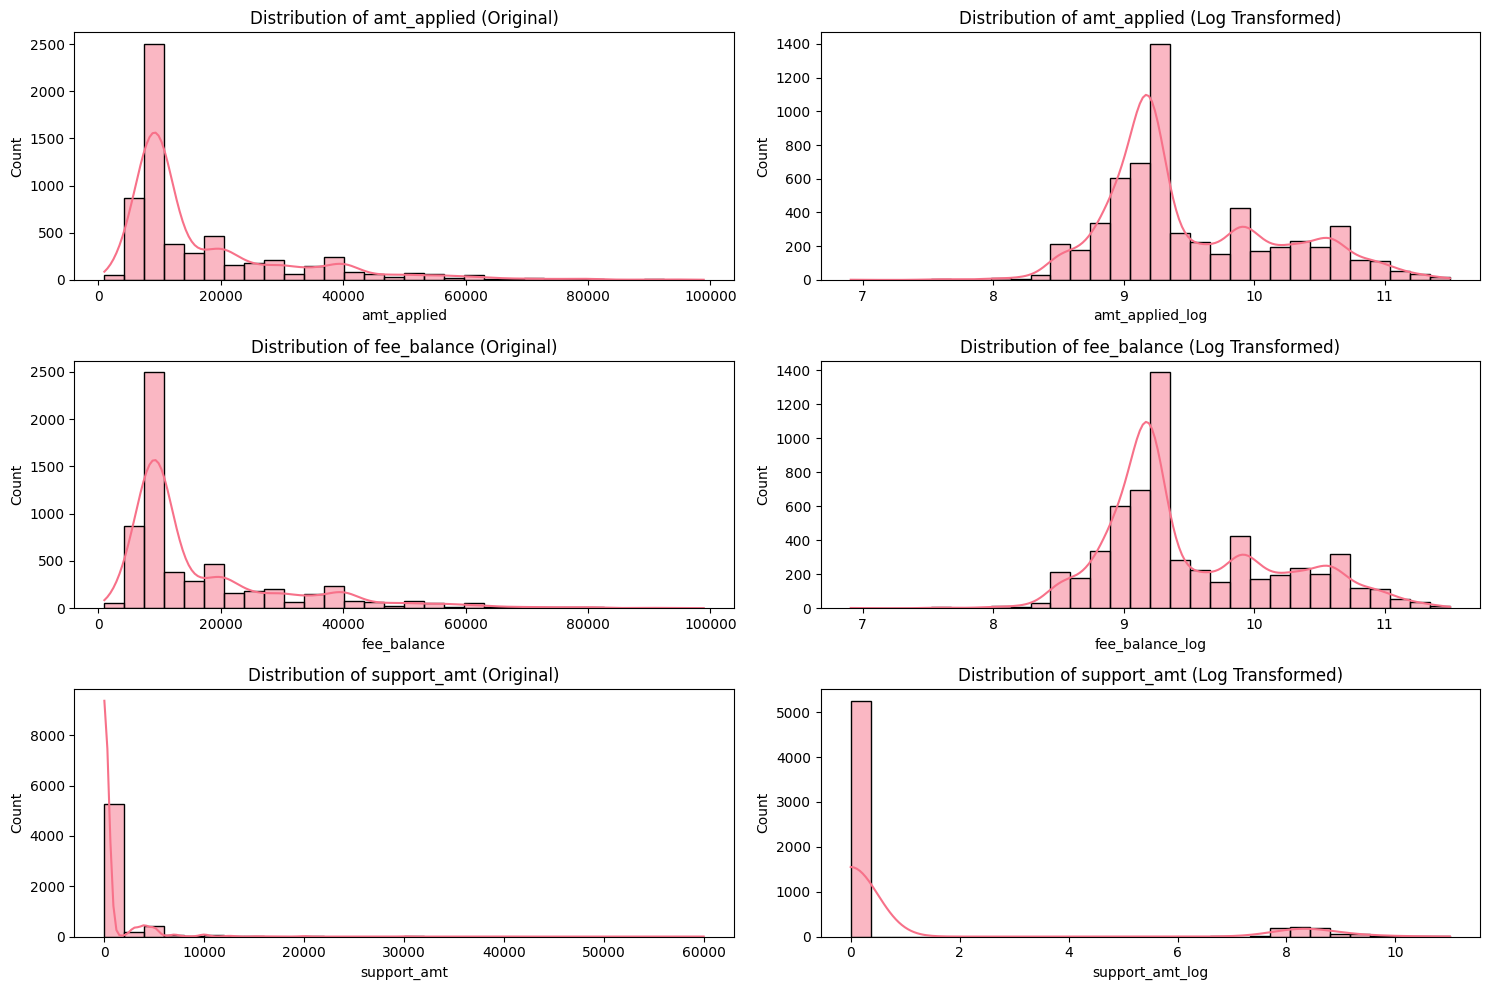

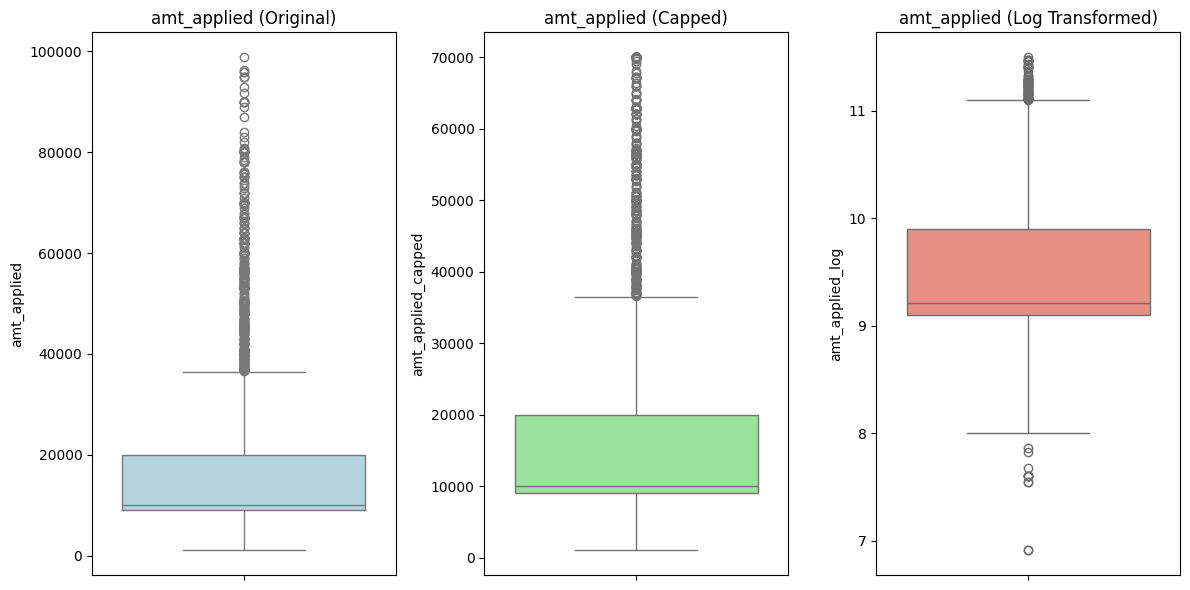

First few rows after handling skewness and outliers:


,Name,app_year,acad_level,acad_perf,School,course_dur,study_mode,exp_completion,amt_applied,fee_balance,...,recommendation,vuln_index,remaining_fee,amt_applied_log,fee_balance_log,support_amt_log,amt_applied_capped,fee_balance_capped,support_amt_capped,has_past_support
0,Anne Kwamboka Omwamba,2021,Secondary School,Good,Great Mercy,4,Day scholar,2022,10000.0,10000.0,...,Approve,0,10000.0,9.210440,9.210440,0.0,10000.0,10000.0,0,0
1,Wafula Violet Nanjala,2021,Secondary School,Excellent,St Josephs Girls High School,4,Boarding,2025,40000.0,40000.0,...,Approve,0,40000.0,10.596660,10.596660,0.0,40000.0,40000.0,0,0
2,John Kibet Watua,2021,Secondary School,Good,St Michael Top Station,4,Boarding,2024,12000.0,12000.0,...,Approve,0,12000.0,9.392745,9.392745,0.0,12000.0,12000.0,0,0
3,Ronny Sang Maru,2021,Secondary School,Fair,Maziwa Secondary School,4,Day scholar,2021,3000.0,3000.0,...,Approve,0,3000.0,8.006701,8.006701,0.0,3000.0,3000.0,0,0
4,Anne Wanjiku Maina,2021,Secondary School,Good,Butere Girls,4,Boarding,2022,20000.0,45000.0,...,Approve,0,45000.0,9.903538,10.714440,0.0,20000.0,45000.0,0,0


In [5]:
# Step 3: Handling Skewness and Outliers
# -----------------------------------------------

# Apply log transformation to handle skewness
data['amt_applied_log'] = np.log1p(data['amt_applied'])
data['fee_balance_log'] = np.log1p(data['fee_balance'])
data['support_amt_log'] = np.log1p(data['support_amt'])

# Cap outliers at the 99th percentile
for col in ['amt_applied', 'fee_balance', 'support_amt']:
    cap_value = data[col].quantile(0.99)
    data[f'{col}_capped'] = data[col].clip(upper=cap_value)

# Create binary feature for past support
data['has_past_support'] = (data['support_amt'] > 0).astype(int)

# Visualizations
plt.figure(figsize=(15, 10))

# Before and After Log Transformation for amt_applied
plt.subplot(3, 2, 1)
sns.histplot(data['amt_applied'], bins=30, kde=True)
plt.title('Distribution of amt_applied (Original)')
plt.subplot(3, 2, 2)
sns.histplot(data['amt_applied_log'], bins=30, kde=True)
plt.title('Distribution of amt_applied (Log Transformed)')

# Before and After Log Transformation for fee_balance
plt.subplot(3, 2, 3)
sns.histplot(data['fee_balance'], bins=30, kde=True)
plt.title('Distribution of fee_balance (Original)')
plt.subplot(3, 2, 4)
sns.histplot(data['fee_balance_log'], bins=30, kde=True)
plt.title('Distribution of fee_balance (Log Transformed)')

# Before and After Log Transformation for support_amt
plt.subplot(3, 2, 5)
sns.histplot(data['support_amt'], bins=30, kde=True)
plt.title('Distribution of support_amt (Original)')
plt.subplot(3, 2, 6)
sns.histplot(data['support_amt_log'], bins=30, kde=True)
plt.title('Distribution of support_amt (Log Transformed)')

plt.tight_layout()
plt.show()

# Boxplot for Capped vs Original vs Log Transformed (amt_applied only, for brevity)
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=data['amt_applied'], color='lightblue')
plt.title('amt_applied (Original)')
plt.subplot(1, 3, 2)
sns.boxplot(y=data['amt_applied_capped'], color='lightgreen')
plt.title('amt_applied (Capped)')
plt.subplot(1, 3, 3)
sns.boxplot(y=data['amt_applied_log'], color='salmon')
plt.title('amt_applied (Log Transformed)')
plt.tight_layout()
plt.show()

# Display the first few rows to confirm changes
print("First few rows after handling skewness and outliers:")
data.head()

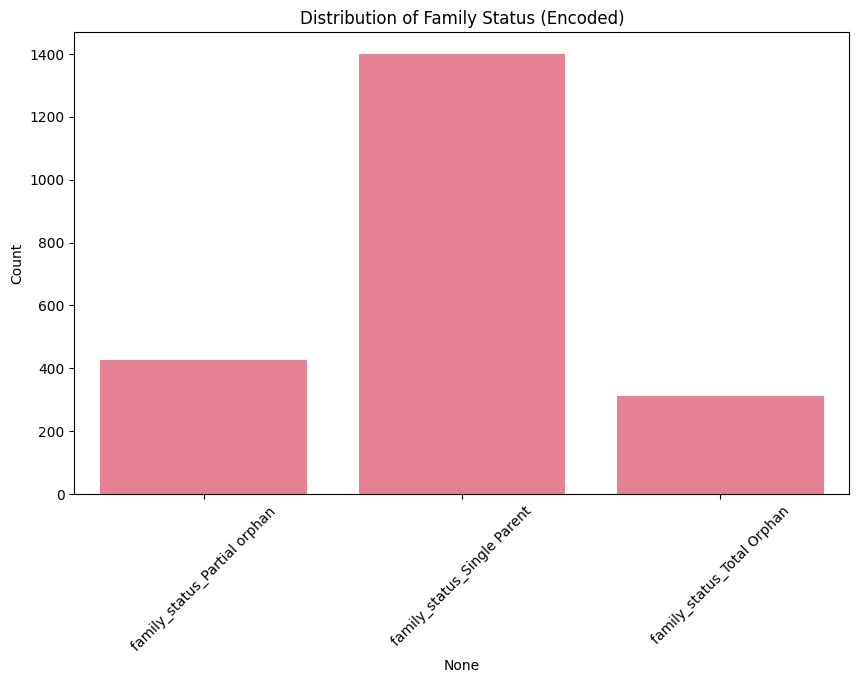

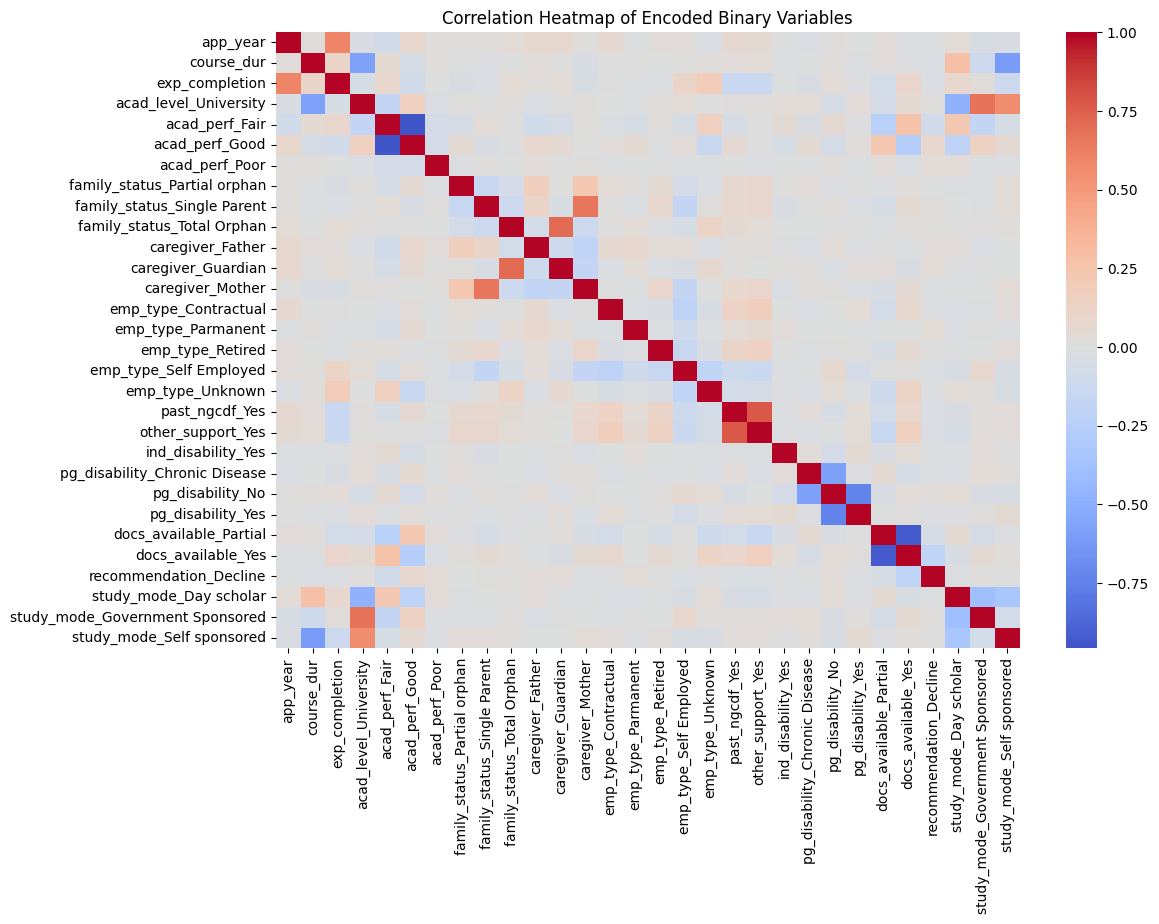

First few rows after categorical encoding:


,app_year,course_dur,exp_completion,amt_applied,fee_balance,support_amt,vuln_index,remaining_fee,amt_applied_log,fee_balance_log,...,ind_disability_Yes,pg_disability_Chronic Disease,pg_disability_No,pg_disability_Yes,docs_available_Partial,docs_available_Yes,recommendation_Decline,study_mode_Day scholar,study_mode_Government Sponsored,study_mode_Self sponsored
0,2021,4,2022,10000.0,10000.0,0,0,10000.0,9.210440,9.210440,...,False,False,True,False,False,True,False,True,False,False
1,2021,4,2025,40000.0,40000.0,0,0,40000.0,10.596660,10.596660,...,False,False,True,False,True,False,False,False,False,False
2,2021,4,2024,12000.0,12000.0,0,0,12000.0,9.392745,9.392745,...,False,False,True,False,True,False,False,False,False,False
3,2021,4,2021,3000.0,3000.0,0,0,3000.0,8.006701,8.006701,...,False,False,True,False,False,True,False,True,False,False
4,2021,4,2022,20000.0,45000.0,0,0,45000.0,9.903538,10.714440,...,False,False,True,False,True,False,False,False,False,False


In [6]:
# Step 4: Categorical Variable Encoding
# -----------------------------------------------

# One-Hot Encoding for categorical variables
categorical_cols = ['acad_level', 'acad_perf', 'family_status', 'caregiver', 'emp_type', 
                    'past_ngcdf', 'other_support', 'ind_disability', 'pg_disability', 
                    'docs_available', 'recommendation', 'study_mode']
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Drop any remaining non-numeric columns that might still exist
non_numeric_cols = data_encoded.select_dtypes(include=['object']).columns
data_encoded = data_encoded.drop(columns=non_numeric_cols, errors='ignore')

# Visualizations
plt.figure(figsize=(10, 6))
family_status_cols = [col for col in data_encoded.columns if 'family_status' in col]
family_status_counts = data_encoded[family_status_cols].sum()
sns.barplot(x=family_status_counts.index, y=family_status_counts.values)
plt.title('Distribution of Family Status (Encoded)')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

# Compute correlation matrix for numeric columns only
plt.figure(figsize=(12, 8))
encoded_binary_cols = [col for col in data_encoded.columns if col not in ['amt_applied', 'fee_balance', 'support_amt', 
                                                                         'amt_applied_log', 'fee_balance_log', 'support_amt_log', 
                                                                         'amt_applied_capped', 'fee_balance_capped', 'support_amt_capped', 
                                                                         'has_past_support', 'vuln_index', 'remaining_fee']]
# Ensure only numeric columns are used for correlation
numeric_cols = data_encoded[encoded_binary_cols].select_dtypes(include=['float64', 'int64', 'bool']).columns
corr_matrix = data_encoded[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Encoded Binary Variables')
plt.show()

# Display the first few rows after encoding
print("First few rows after categorical encoding:")
display(data_encoded.head())

First few rows after feature engineering:


,app_year,course_dur,exp_completion,amt_applied,fee_balance,support_amt,vuln_index,remaining_fee,amt_applied_log,fee_balance_log,...,recommendation_Decline,study_mode_Day scholar,study_mode_Government Sponsored,study_mode_Self sponsored,years_remaining,course_completion_ratio,academic_stability,vulnerability_score,log_financial_burden,past_support_impact
0,2021,4,2022,10000.0,10000.0,0,0,10000.0,9.210440,9.210440,...,False,True,False,False,1,0.25,3,3.870045,9.210440,0.0
1,2021,4,2025,40000.0,40000.0,0,0,40000.0,10.596660,10.596660,...,False,False,False,False,4,1.00,1,5.262130,10.596660,0.0
2,2021,4,2024,12000.0,12000.0,0,0,12000.0,9.392745,9.392745,...,False,False,False,False,3,0.75,3,4.120177,9.392745,0.0
3,2021,4,2021,3000.0,3000.0,0,0,3000.0,8.006701,8.006701,...,False,True,False,False,0,0.00,2,3.756182,8.006701,0.0
4,2021,4,2022,20000.0,45000.0,0,0,45000.0,9.903538,10.714440,...,False,False,False,False,1,0.25,3,4.318137,10.308989,0.0


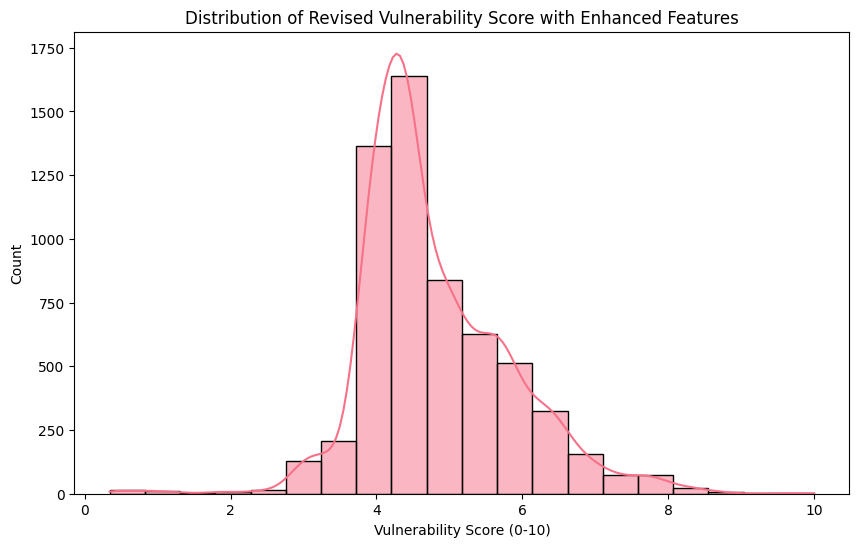

Vulnerability Score Summary:
count    6021.000000
mean        4.804126
std         1.026664
min         0.342679
25%         4.127024
50%         4.547060
75%         5.405192
max        10.000000
Name: vulnerability_score, dtype: float64
Number of entries with vulnerability_score = 0: 0


In [7]:
# Step 5: Feature Engineering
# -----------------------------------------------

# Remaining Fee: Unmet financial need
data_encoded['remaining_fee'] = (data_encoded['fee_balance'] - data_encoded['support_amt']).clip(lower=0)

# Course Completion Ratio (Already moved up in previous fix)
data_encoded['years_remaining'] = data_encoded['exp_completion'] - data_encoded['app_year']
data_encoded['course_completion_ratio'] = data_encoded['years_remaining'] / data_encoded['course_dur']
data_encoded['course_completion_ratio'].fillna(data_encoded['course_completion_ratio'].mean(), inplace=True)

# Academic Stability: Weighted score based on academic performance (Moved up to be computed before vulnerability_score)
data_encoded['academic_stability'] = (
    4 * data_encoded.get('acad_perf_Excellent', 0) + 
    3 * data_encoded.get('acad_perf_Good', 0) + 
    2 * data_encoded.get('acad_perf_Fair', 0) + 
    1 * (1 - (data_encoded.get('acad_perf_Excellent', 0) + 
              data_encoded.get('acad_perf_Good', 0) + 
              data_encoded.get('acad_perf_Fair', 0)))  # Poor as reference
)

# Revised Vulnerability Score: Broader range with more features
data_encoded['vulnerability_score'] = (
    3 * data_encoded.get('ind_disability_Yes', 0) +  # Individual disability
    2 * data_encoded.get('pg_disability_Yes', 0) +   # Parent/Guardian disability
    2 * data_encoded.get('pg_disability_Chronic Disease', 0) +  # Chronic disease
    4 * data_encoded.get('pg_disability_Both', 0) +  # Severe case: both disability and chronic disease
    3 * data_encoded.get('family_status_Total Orphan', 0) +  # Total orphan
    2 * data_encoded.get('family_status_Partial orphan', 0) +  # Partial orphan
    1 * data_encoded.get('family_status_Single Parent', 0) +  # Single parent
    1 * (1 - data_encoded['has_past_support']) +  # Lack of past support increases vulnerability
    np.log1p(data_encoded['remaining_fee']) / np.log1p(data_encoded['remaining_fee'].max()) * 5 +  # Scaled financial burden (0-5)
    (data_encoded['course_completion_ratio'] / data_encoded['course_completion_ratio'].max()) * 2 +  # Remaining course duration (0-2)
    (1 - data_encoded['academic_stability'] / 4) * 2 +  # Lower academic stability increases vulnerability (0-2)
    1 * data_encoded.get('docs_available_No', 0) +  # Lack of full documentation (0-1)
    2 * data_encoded.get('emp_type_Casual', 0) +  # Unstable employment (0-2)
    1 * data_encoded.get('emp_type_Unemployed', 0) +  # No employment (0-1)
    1 * data_encoded.get('study_mode_Boarding', 0) +  # Higher cost of boarding (0-1)
    2 * data_encoded.get('acad_level_University', 0)  # Higher education level increases financial need (0-2)
).fillna(0)

# Normalize vulnerability_score to 0-10 range
max_vuln = data_encoded['vulnerability_score'].max()
if max_vuln > 0:
    data_encoded['vulnerability_score'] = (data_encoded['vulnerability_score'] / max_vuln) * 10
else:
    data_encoded['vulnerability_score'] = 0

# Log Financial Burden: Average of log-transformed financial metrics
data_encoded['log_financial_burden'] = (data_encoded['amt_applied_log'] + data_encoded['fee_balance_log']) / 2
data_encoded['log_financial_burden'].fillna(data_encoded['log_financial_burden'].mean(), inplace=True)

# Past Support Impact: Scaled impact of past support
data_encoded['past_support_impact'] = data_encoded['has_past_support'] * (data_encoded['support_amt_capped'] / data_encoded['support_amt_capped'].max())
data_encoded['past_support_impact'].fillna(0, inplace=True)

# Display the first few rows
print("First few rows after feature engineering:")
display(data_encoded.head())

# Visualization to check the new vulnerability_score distribution
plt.figure(figsize=(10, 6))
sns.histplot(data_encoded['vulnerability_score'], bins=20, kde=True)
plt.title('Distribution of Revised Vulnerability Score with Enhanced Features')
plt.xlabel('Vulnerability Score (0-10)')
plt.ylabel('Count')
plt.show()

# Summary of vulnerability_score
print("Vulnerability Score Summary:")
print(data_encoded['vulnerability_score'].describe())
print(f"Number of entries with vulnerability_score = 0: {(data_encoded['vulnerability_score'] == 0).sum()}")

Learned Weights for Financial Need Score:
remaining_fee_transformed           12917.562964
vulnerability_score_transformed      -839.457072
log_financial_burden_transformed     1177.491485
course_completion_ratio               218.168093
past_support_impact                  3436.160935
dtype: float64
First few rows after adding financial need score:


,app_year,course_dur,exp_completion,amt_applied,fee_balance,support_amt,vuln_index,remaining_fee,amt_applied_log,fee_balance_log,...,years_remaining,course_completion_ratio,academic_stability,vulnerability_score,log_financial_burden,past_support_impact,remaining_fee_transformed,vulnerability_score_transformed,log_financial_burden_transformed,financial_need_score
0,2021,4,2022,10000.0,10000.0,0,0,10000.0,9.210440,9.210440,...,1,-0.737892,3,3.870045,9.210440,-0.343323,-0.343288,-0.909645,-0.346967,39.354148
1,2021,4,2025,40000.0,40000.0,0,0,40000.0,10.596660,10.596660,...,4,1.340861,1,5.262130,10.596660,-0.343323,1.591808,0.481109,1.504366,84.146112
2,2021,4,2024,12000.0,12000.0,0,0,12000.0,9.392745,9.392745,...,3,0.647943,3,4.120177,9.392745,-0.343323,-0.127705,-0.647291,-0.030320,45.560431
3,2021,4,2021,3000.0,3000.0,0,0,3000.0,8.006701,8.006701,...,0,-1.430810,2,3.756182,8.006701,-0.343323,-1.531790,-1.031146,-3.359977,12.096884
4,2021,4,2022,20000.0,45000.0,0,0,45000.0,9.903538,10.714440,...,1,-0.737892,3,4.318137,10.308989,-0.343323,1.791558,-0.443862,1.209218,86.804621


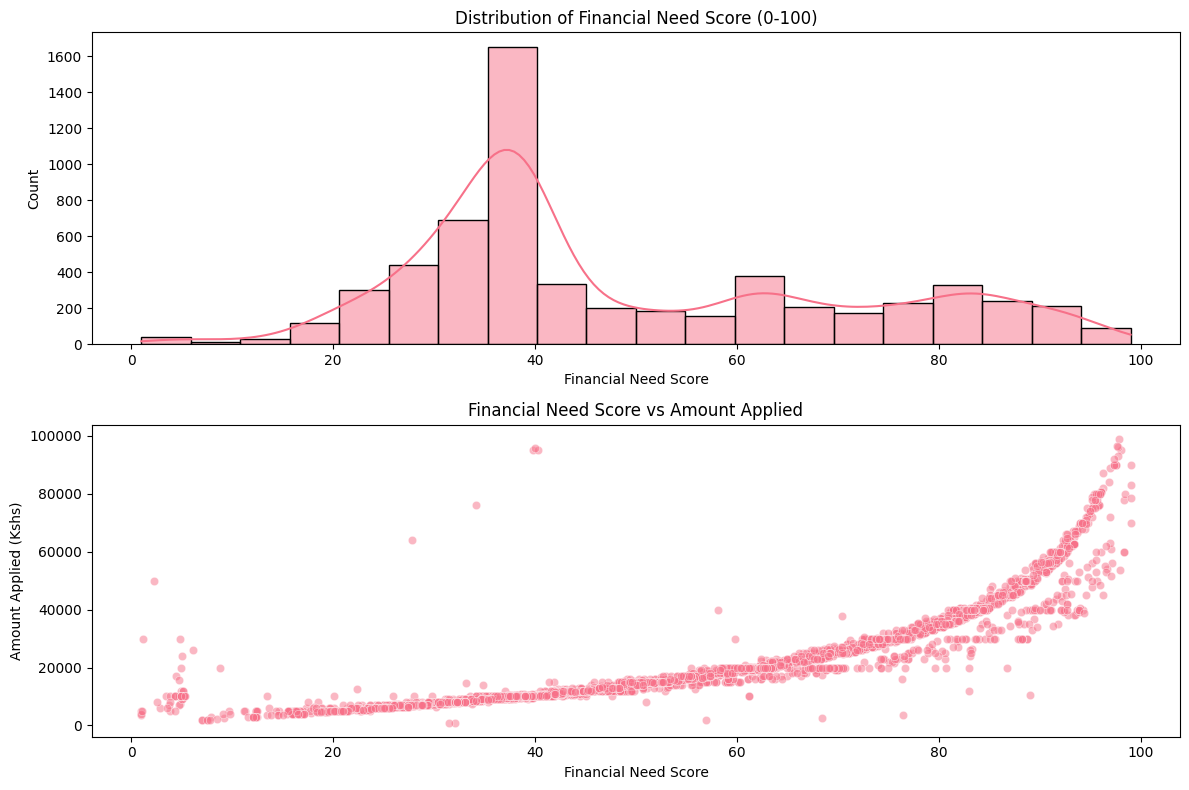

Financial Need Score Summary:
count    6021.000000
mean       48.717190
std        21.384224
min         1.000000
25%        34.526995
50%        39.301374
75%        63.838180
max        99.000000
Name: financial_need_score, dtype: float64

Correlations with Financial Need Score:
amt_applied: 0.8971
fee_balance: 0.9130
vulnerability_score: 0.4064

Mean Financial Need Score by Family Status:
family_status_Partial orphan: 48.69
family_status_Single Parent: 49.08
family_status_Total Orphan: 47.06


In [8]:
# Step 6: Financial Need Score (Achieve Balanced Distribution with Sigmoid Transformation)
# -----------------------------------------------

# Define the features used to compute the financial need score
features_for_score = ['remaining_fee', 'vulnerability_score', 'log_financial_burden', 
                     'course_completion_ratio', 'past_support_impact']

# Apply Yeo-Johnson transformation to features to reduce skewness
pt = PowerTransformer(method='yeo-johnson', standardize=False)
for feature in ['remaining_fee', 'vulnerability_score', 'log_financial_burden']:
    data_encoded[f'{feature}_transformed'] = pt.fit_transform(data_encoded[[feature]])
    features_for_score = [f'{feature}_transformed' if feature in ['remaining_fee', 'vulnerability_score', 'log_financial_burden'] else feature for feature in features_for_score]

# Standardize features to balance their contributions
scaler_std = StandardScaler()
data_encoded[features_for_score] = scaler_std.fit_transform(data_encoded[features_for_score])

# Prepare data for regression to learn weights
X_score = data_encoded[features_for_score].fillna(0)
y_score = data_encoded['amt_applied'].fillna(data_encoded['amt_applied'].median())

# Train a Ridge regression model to learn the weights
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_score, y_score)

# Extract the learned coefficients as weights
learned_weights = pd.Series(ridge_model.coef_, index=features_for_score)
learned_weights_dict = learned_weights.to_dict()
print("Learned Weights for Financial Need Score:")
print(learned_weights)

# Calculate Financial Need Score using the learned weights
data_encoded['financial_need_score'] = (
    sum(learned_weights_dict[feature] * data_encoded[feature] for feature in features_for_score) +
    0.1 * (data_encoded['remaining_fee_transformed'] * data_encoded['vulnerability_score_transformed'])
)

# Standardize the raw financial_need_score before sigmoid transformation
data_encoded['financial_need_score'] = (data_encoded['financial_need_score'] - data_encoded['financial_need_score'].mean()) / data_encoded['financial_need_score'].std()

# Apply sigmoid transformation to balance the distribution
data_encoded['financial_need_score'] = expit(data_encoded['financial_need_score'])

# Scale the transformed scores to 0-100 with clipping to avoid extremes
min_score = data_encoded['financial_need_score'].min()
max_score = data_encoded['financial_need_score'].max()
if max_score > min_score:
    data_encoded['financial_need_score'] = 100 * (data_encoded['financial_need_score'] - min_score) / (max_score - min_score)
else:
    data_encoded['financial_need_score'] = 0

# Clip the scores to avoid extreme values
data_encoded['financial_need_score'] = data_encoded['financial_need_score'].clip(lower=1, upper=99)

# Display the first few rows
print("First few rows after adding financial need score:")
display(data_encoded.head())

# Visualization to check the financial_need_score distribution
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
sns.histplot(data_encoded['financial_need_score'], bins=20, kde=True)
plt.title('Distribution of Financial Need Score (0-100)')
plt.xlabel('Financial Need Score')
plt.ylabel('Count')

# Scatter plot to validate against amt_applied
plt.subplot(2, 1, 2)
sns.scatterplot(x=data_encoded['financial_need_score'], y=data_encoded['amt_applied'], alpha=0.5)
plt.title('Financial Need Score vs Amount Applied')
plt.xlabel('Financial Need Score')
plt.ylabel('Amount Applied (Kshs)')
plt.tight_layout()
plt.show()

# Summary of financial_need_score
print("Financial Need Score Summary:")
print(data_encoded['financial_need_score'].describe())

# Correlation with key indicators
print("\nCorrelations with Financial Need Score:")
for col in ['amt_applied', 'fee_balance', 'vulnerability_score']:
    corr = data_encoded['financial_need_score'].corr(data_encoded[col])
    print(f"{col}: {corr:.4f}")

# Fairness check across family_status
print("\nMean Financial Need Score by Family Status:")
family_status_cols = [col for col in data_encoded.columns if 'family_status' in col]
for col in family_status_cols:
    mean_score = data_encoded.loc[data_encoded[col] == 1, 'financial_need_score'].mean()
    print(f"{col}: {mean_score:.2f}")

In [9]:
print("Columns in data_encoded:")
print(data_encoded.columns.tolist())

Columns in data_encoded:
['app_year', 'course_dur', 'exp_completion', 'amt_applied', 'fee_balance', 'support_amt', 'vuln_index', 'remaining_fee', 'amt_applied_log', 'fee_balance_log', 'support_amt_log', 'amt_applied_capped', 'fee_balance_capped', 'support_amt_capped', 'has_past_support', 'acad_level_University', 'acad_perf_Fair', 'acad_perf_Good', 'acad_perf_Poor', 'family_status_Partial orphan', 'family_status_Single Parent', 'family_status_Total Orphan', 'caregiver_Father', 'caregiver_Guardian', 'caregiver_Mother', 'emp_type_Contractual', 'emp_type_Parmanent', 'emp_type_Retired', 'emp_type_Self Employed', 'emp_type_Unknown', 'past_ngcdf_Yes', 'other_support_Yes', 'ind_disability_Yes', 'pg_disability_Chronic Disease', 'pg_disability_No', 'pg_disability_Yes', 'docs_available_Partial', 'docs_available_Yes', 'recommendation_Decline', 'study_mode_Day scholar', 'study_mode_Government Sponsored', 'study_mode_Self sponsored', 'years_remaining', 'course_completion_ratio', 'academic_stability'

In [12]:
import joblib

=== PCA Explained Variance Ratio ===
Number of components: 4
Cumulative explained variance: 0.6589
Individual explained variance ratios: [0.2172229  0.18937641 0.1274436  0.12482631]


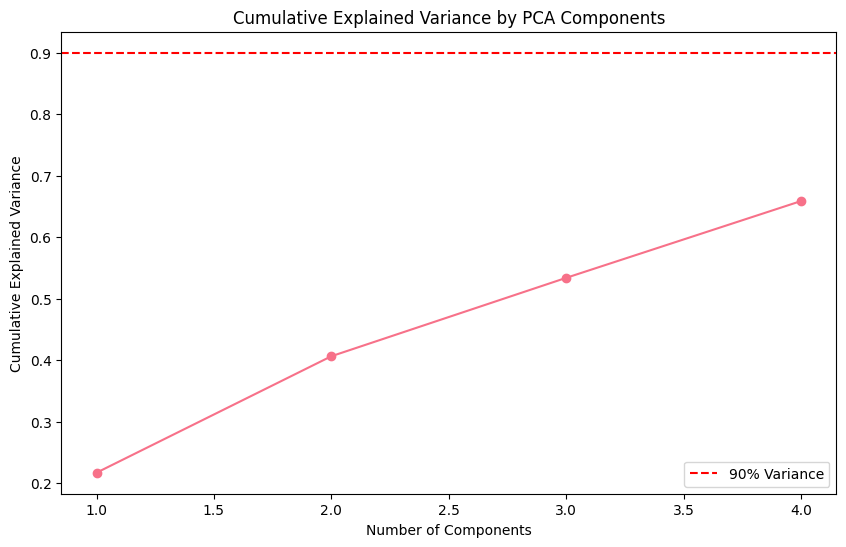


=== Top 10 Features by Mutual Information ===
                             Feature  MI Score
31   vulnerability_score_transformed  3.227099
27               vulnerability_score  3.222730
32  log_financial_burden_transformed  2.636335
28              log_financial_burden  2.634393
30         remaining_fee_transformed  2.624082
2                      remaining_fee  2.603548
0                        amt_applied  2.597527
25           course_completion_ratio  0.842947
26                academic_stability  0.371743
5                     acad_perf_Fair  0.371286

=== Features After Removing Duplicates ===
['PC1', 'PC2', 'PC3', 'PC4', 'amt_applied', 'remaining_fee', 'acad_perf_Fair', 'course_completion_ratio', 'academic_stability', 'vulnerability_score', 'log_financial_burden', 'remaining_fee_transformed', 'vulnerability_score_transformed', 'log_financial_burden_transformed', 'financial_need_score']

=== PCA Reduced Data Shape ===
Rows: 6021, Columns: 4

=== Combined Reduced Data Shape ===
R

['pca.joblib']

In [13]:
# Step 7: Dimensionality Reduction and Feature Selection
# -----------------------------------------------

# Exclude only raw precursors for PCA, but keep engineered features for feature selection
features_to_exclude_for_pca = [
    'fee_balance', 'support_amt', 'amt_applied_log', 'fee_balance_log', 'support_amt_log', 
    'amt_applied_capped', 'fee_balance_capped', 'support_amt_capped', 
    'ind_disability_Yes', 'pg_disability_Yes', 'pg_disability_Chronic Disease', 
    'pg_disability_Both', 'family_status_Total Orphan', 'family_status_Partial orphan', 
    'family_status_Single Parent', 'exp_completion', 'app_year', 'course_dur'
]
data_for_pca = data_encoded.drop(columns=features_to_exclude_for_pca, errors='ignore')

# Define features for PCA (match the actual columns in data_encoded, excluding 'amt_applied')
pca_features = [
    'vuln_index',
    'acad_level_University',  # 'acad_level_Secondary School' is the reference category (not in data_encoded)
    'caregiver_Guardian',
    'past_ngcdf_Yes',  # 'past_ngcdf_No' is the reference category (not in data_encoded)
    'other_support_Yes',  # 'other_support_No' is the reference category (not in data_encoded)
    'pg_disability_No',
    'study_mode_Day scholar', 'study_mode_Government Sponsored', 'study_mode_Self sponsored',  # 'study_mode_Boarding' is the reference category (not in data_encoded)
    'years_remaining',
    'course_completion_ratio', 'acad_perf_Good',
    'past_support_impact', 'log_financial_burden'
]

# Extract the PCA features from the DataFrame
numerical_features = data_for_pca[pca_features].fillna(data_for_pca[pca_features].mean(numeric_only=True))

# Standardize numerical features
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_features)

# Apply PCA to reduce to 4 components (to match the expected output in app.py)
pca = PCA(n_components=4)  # Retain 4 components (PC1, PC2, PC3, PC4)
numerical_pca = pca.fit_transform(numerical_scaled)

# Create DataFrame for PCA components
pca_columns = [f'PC{i+1}' for i in range(numerical_pca.shape[1])]
data_pca = pd.DataFrame(numerical_pca, columns=pca_columns, index=data_for_pca.index)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("=== PCA Explained Variance Ratio ===")
print(f"Number of components: {len(explained_variance)}")
print(f"Cumulative explained variance: {sum(explained_variance):.4f}")
print(f"Individual explained variance ratios: {explained_variance}")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.legend()
plt.show()

# Feature Selection using Mutual Information, including engineered features
features_to_exclude_for_selection = [
    'fee_balance', 'support_amt', 'amt_applied_log', 'fee_balance_log', 'support_amt_log', 
    'amt_applied_capped', 'fee_balance_capped', 'support_amt_capped', 
    'ind_disability_Yes', 'pg_disability_Yes', 'pg_disability_Chronic Disease', 
    'pg_disability_Both', 'family_status_Total Orphan', 'family_status_Partial orphan', 
    'family_status_Single Parent', 'exp_completion', 'app_year', 'course_dur',
    'years_remaining'  # Drop years_remaining to avoid redundancy with course_completion_ratio
]
data_for_selection = data_encoded.drop(columns=features_to_exclude_for_selection, errors='ignore')

# Standardize features for feature selection to reduce dominance of large-scale features
scaler_selection = StandardScaler()
X = data_for_selection.drop(columns=['financial_need_score'])
X_scaled = scaler_selection.fit_transform(X.fillna(X.mean(numeric_only=True)).fillna(0))
y = data_for_selection['financial_need_score'].fillna(data_for_selection['financial_need_score'].mean())

k_best = SelectKBest(score_func=mutual_info_regression, k=10)  # Reduce to top 10 features
X_selected = k_best.fit_transform(X_scaled, y)

# Get selected feature names
selected_indices = k_best.get_support(indices=True)
selected_features = X.columns[selected_indices].tolist()
feature_scores = pd.DataFrame({'Feature': X.columns, 'MI Score': k_best.scores_})
feature_scores = feature_scores.sort_values(by='MI Score', ascending=False)

print("\n=== Top 10 Features by Mutual Information ===")
print(feature_scores.head(10))

# Create reduced DataFrame with PCA components, selected features, and key engineered features
data_final = pd.concat([data_pca, data_for_selection[selected_features], 
                        data_encoded[['financial_need_score', 'vulnerability_score', 'amt_applied']]], axis=1)

# Remove duplicate columns
data_final = data_final.loc[:, ~data_final.columns.duplicated()]
print("\n=== Features After Removing Duplicates ===")
print(data_final.columns.tolist())

# Normalize all features in data_final to 0-1 range for consistency
final_features = [col for col in data_final.columns if col not in ['financial_need_score', 'vulnerability_score', 'amt_applied']]
minmax_scaler = MinMaxScaler()
data_final[final_features] = minmax_scaler.fit_transform(data_final[final_features])

# Fill any NaNs in data_final to ensure downstream steps work
data_final = data_final.fillna(data_final.mean(numeric_only=True))

# Display info for reduced datasets
print("\n=== PCA Reduced Data Shape ===")
print(f"Rows: {data_pca.shape[0]}, Columns: {data_pca.shape[1]}")

print("\n=== Combined Reduced Data Shape ===")
print(f"Rows: {data_final.shape[0]}, Columns: {data_final.shape[1]}")

# Summary of combined reduced data
print("\n=== Combined Reduced Data Summary ===")
print(data_final.describe())

# Update X and y for the next steps
X = data_final.drop(columns=['financial_need_score'])
y = data_final['financial_need_score']

# Remove features with low variance
print("\n=== Step 7: Variance Thresholding ===")
print(f"Initial Features: {X.columns.tolist()}")
print(f"Initial Shape: {X.shape}")

# Check for PCA features
pca_features = [col for col in X.columns if col.startswith('PC')]
if not pca_features:
    print("\n=== Warning: No PCA Features Detected ===")
else:
    print(f"\n=== PCA Features Present: {pca_features} ===")

# Remove features with low variance
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices].tolist()
print("\n=== Features After Variance Thresholding ===")
print(selected_features)

# Convert back to DataFrame
X_selected_df = pd.DataFrame(X_selected, columns=selected_features, index=X.index)

# Ensure required features for RL are included
required_features = ['course_completion_ratio', 'acad_perf_Good', 'past_support_impact']
missing_required = [feat for feat in required_features if feat not in selected_features]
if missing_required:
    print(f"\n=== Adding Missing Required Features: {missing_required} ===")
    # Add the missing required features back to the DataFrame
    for feat in missing_required:
        if feat in X.columns:
            X_selected_df[feat] = X[feat]
        else:
            print(f"Warning: {feat} not found in original data")

# Verify the final feature set
print("\n=== Final Features After Step 7 ===")
print(X_selected_df.columns.tolist())
print(f"Final Shape: {X_selected_df.shape}")

# Update X for the next steps
X = X_selected_df

# Save the updated PCA object
joblib.dump(pca, 'pca.joblib')

In [14]:
# Step 8: Data Splitting
# -----------------------------------------------

# Split the data into training (70%), validation (15%), and test (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert to numpy arrays
X_train_np = X_train.to_numpy()
X_val_np = X_val.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

# Verify the shapes and feature names
print("\n=== Step 8: Data Splitting ===")
print(f"X_train shape: {X_train_np.shape}")
print(f"X_val shape: {X_val_np.shape}")
print(f"X_test shape: {X_test_np.shape}")
print(f"y_train shape: {y_train_np.shape}")
print(f"y_val shape: {y_val_np.shape}")
print(f"y_test shape: {y_test_np.shape}")
print(f"Feature Names: {X_train.columns.tolist()}")


=== Step 8: Data Splitting ===
X_train shape: (4214, 12)
X_val shape: (903, 12)
X_test shape: (904, 12)
y_train shape: (4214,)
y_val shape: (903,)
y_test shape: (904,)
Feature Names: ['PC1', 'PC2', 'PC3', 'amt_applied', 'remaining_fee', 'acad_perf_Fair', 'academic_stability', 'vulnerability_score', 'log_financial_burden', 'remaining_fee_transformed', 'log_financial_burden_transformed', 'course_completion_ratio']



=== Initial Feature Names ===
['PC1', 'PC2', 'PC3', 'amt_applied', 'remaining_fee', 'acad_perf_Fair', 'academic_stability', 'vulnerability_score', 'log_financial_burden', 'remaining_fee_transformed', 'log_financial_burden_transformed', 'course_completion_ratio']

=== Excluded Features ===
['remaining_fee', 'vulnerability_score', 'amt_applied']
Exclude Indices: [3, 4, 7]

=== Feature Names After Exclusion ===
['PC1', 'PC2', 'PC3', 'acad_perf_Fair', 'academic_stability', 'log_financial_burden', 'remaining_fee_transformed', 'log_financial_burden_transformed', 'course_completion_ratio']

=== WARNING: Missing Required Features ===
['acad_perf_Good', 'past_support_impact']

=== Top 5 Features Selected by SelectKBest ===
['PC1', 'PC2', 'log_financial_burden', 'remaining_fee_transformed', 'log_financial_burden_transformed']

=== Mutual Information Scores for All Features ===
                            Feature  MI Score
7  log_financial_burden_transformed  2.585737
5              log_financia

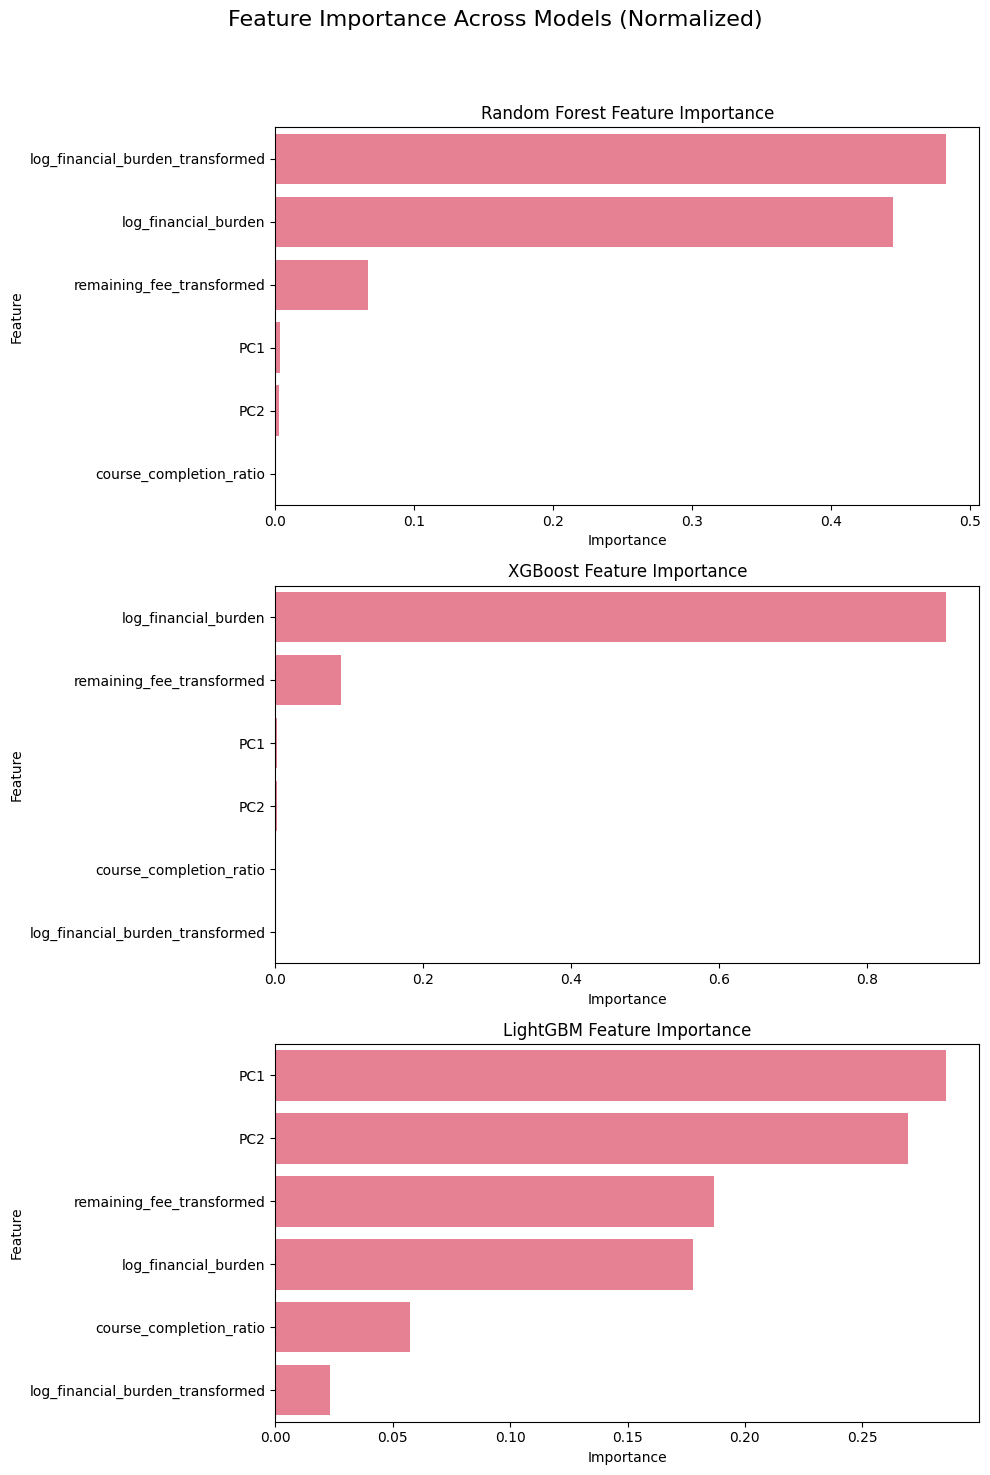

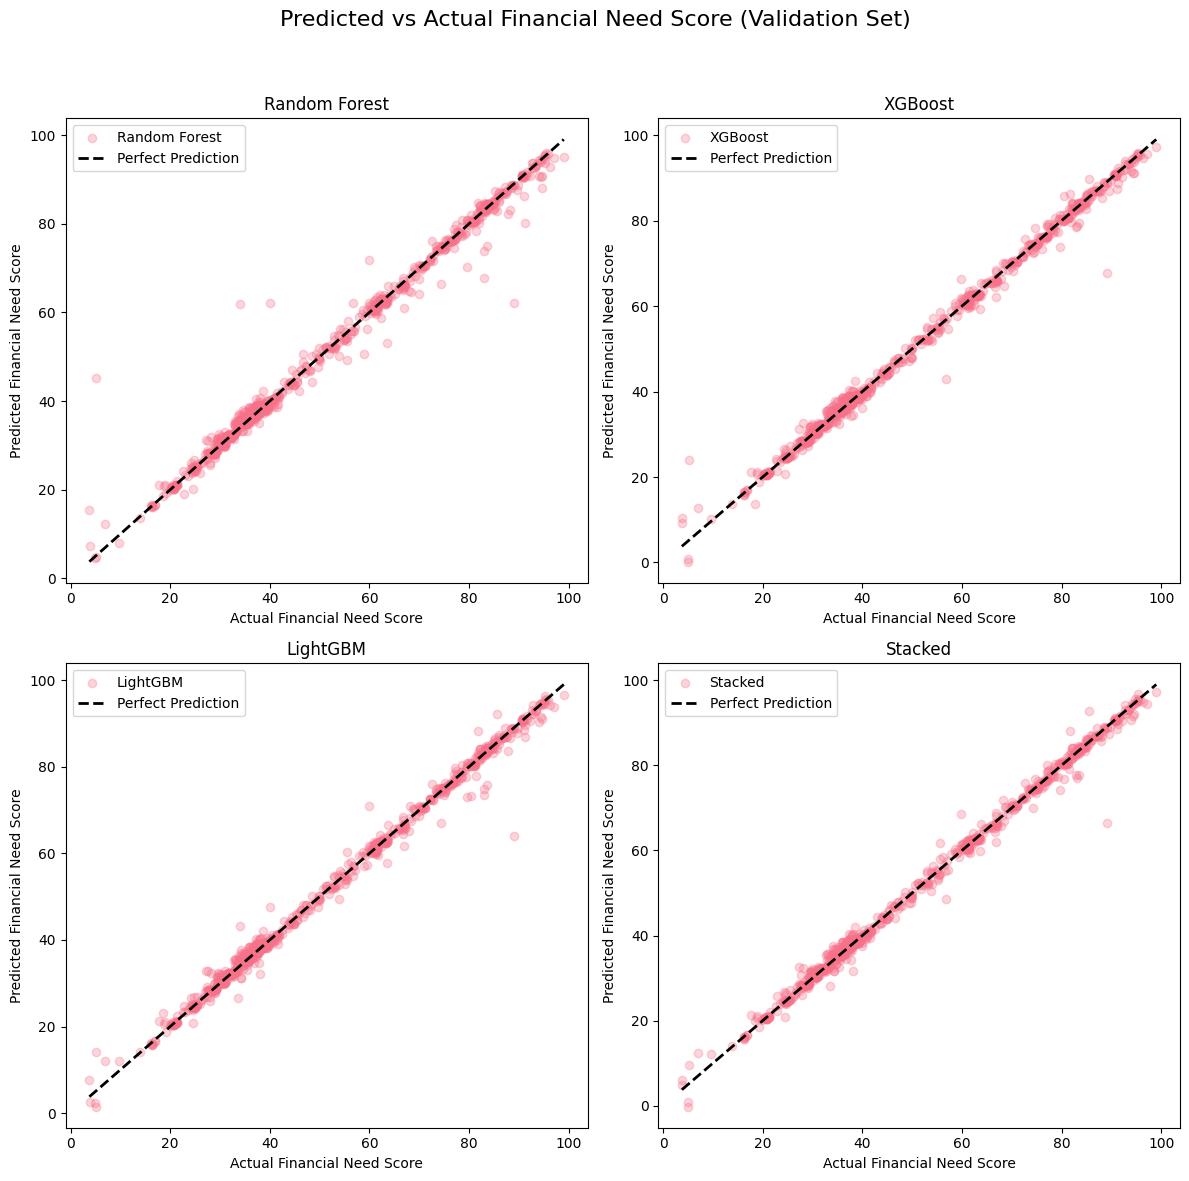

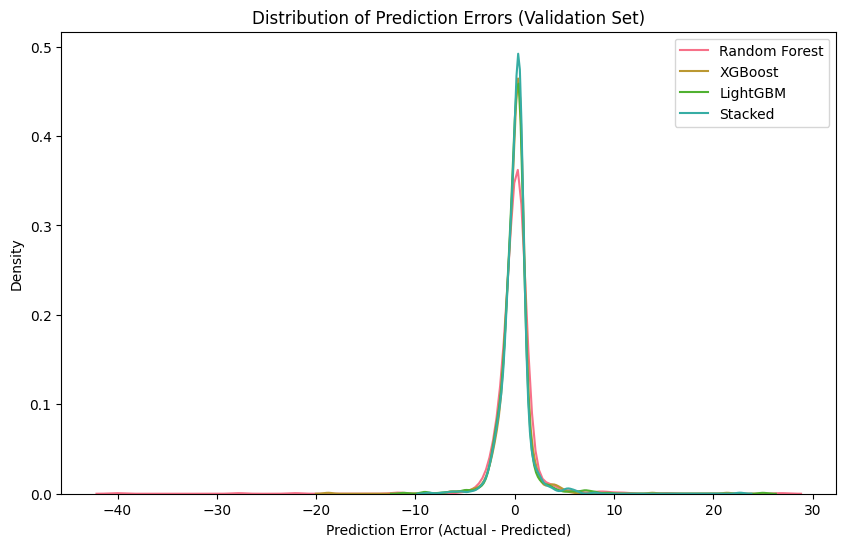

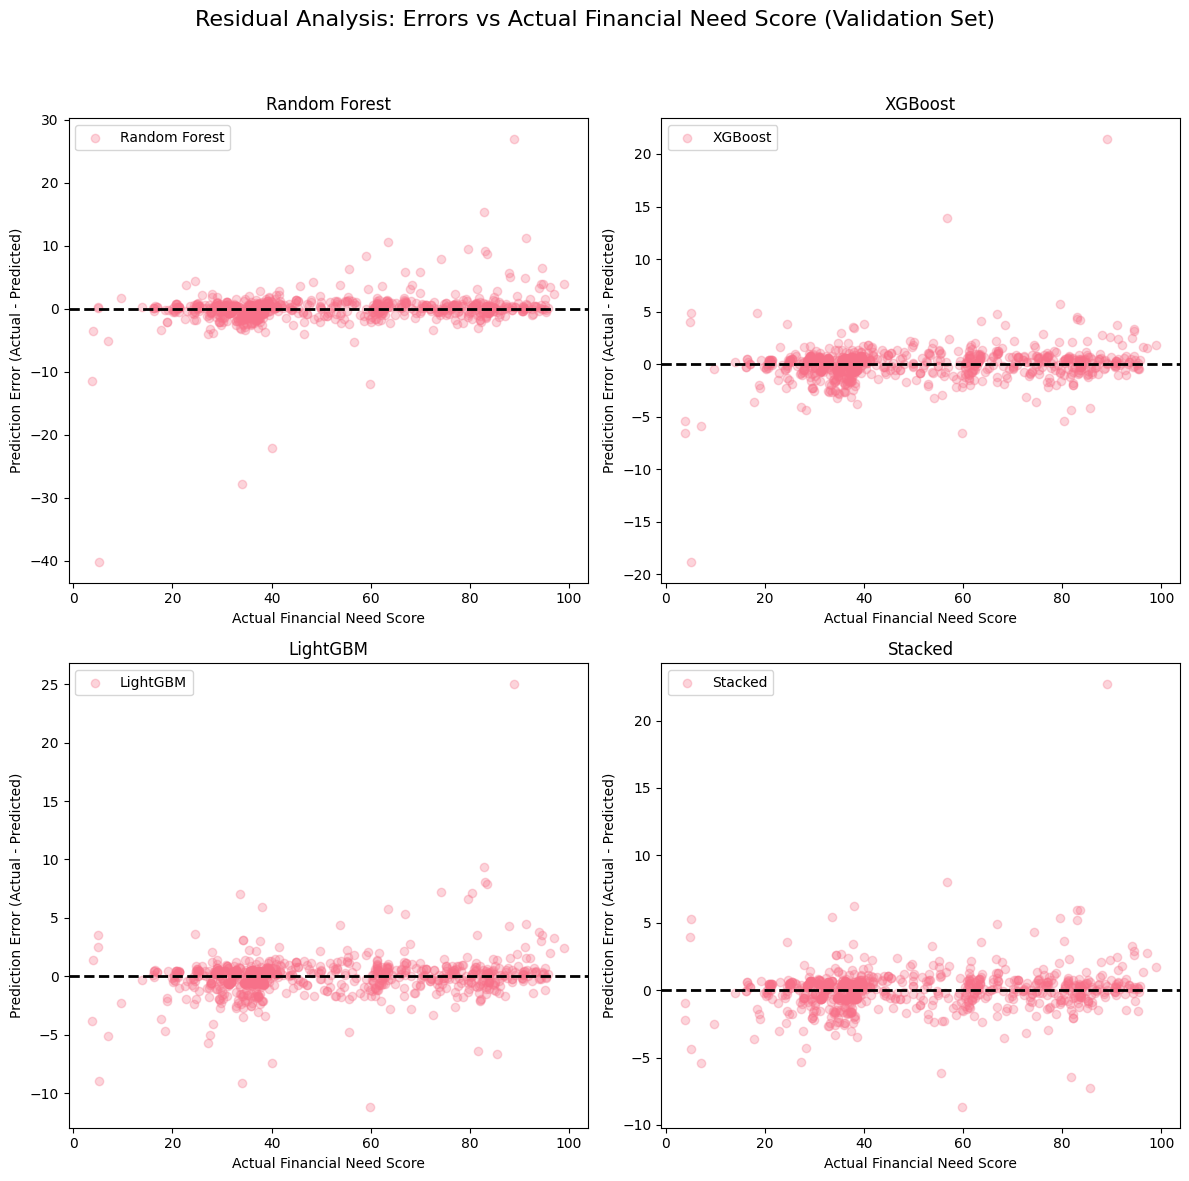

In [15]:
# Step 9: Supervised Learning
# -----------------------------------------------

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold


# Get feature names for interpretability (from X_train columns)
feature_names = X_train.columns.tolist()
print("\n=== Initial Feature Names ===")
print(feature_names)

# Identify indices of features to exclude (to avoid data leakage)
features_to_exclude = ['remaining_fee', 'vulnerability_score', 'amt_applied']
exclude_indices = []
for feat in features_to_exclude:
    indices = [i for i, name in enumerate(feature_names) if name == feat]
    exclude_indices.extend(indices)
exclude_indices = sorted(list(set(exclude_indices)))  # Remove duplicates and sort
print("\n=== Excluded Features ===")
print(features_to_exclude)
print("Exclude Indices:", exclude_indices)

# Keep indices of features to retain
keep_indices = [i for i in range(X_train_np.shape[1]) if i not in exclude_indices]

# Exclude the specified features from the numpy arrays
X_train_np = X_train_np[:, keep_indices]
X_val_np = X_val_np[:, keep_indices]
X_test_np = X_test_np[:, keep_indices]

# Update feature names after exclusion
feature_names = [feature_names[i] for i in keep_indices]
print("\n=== Feature Names After Exclusion ===")
print(feature_names)

# Verify that required features are in feature_names
required_features = ['course_completion_ratio', 'acad_perf_Good', 'past_support_impact']
missing_features = [feat for feat in required_features if feat not in feature_names]
if missing_features:
    print(f"\n=== WARNING: Missing Required Features ===")
    print(missing_features)
else:
    print("\n=== All Required Features Present ===")

# Feature Selection: Select top 5 features based on mutual information
k_best = SelectKBest(score_func=mutual_info_regression, k=5)
X_train_np_selected = k_best.fit_transform(X_train_np, y_train_np)
X_val_np_selected = k_best.transform(X_val_np)
X_test_np_selected = k_best.transform(X_test_np)

# Get selected feature indices and names
selected_indices = k_best.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]
print("\n=== Top 5 Features Selected by SelectKBest ===")
print(selected_feature_names)

# Log mutual information scores for all features
mi_scores = pd.DataFrame({'Feature': feature_names, 'MI Score': k_best.scores_})
mi_scores = mi_scores.sort_values(by='MI Score', ascending=False)
print("\n=== Mutual Information Scores for All Features ===")
print(mi_scores)

# Add required features for RL (course_completion_ratio, acad_perf_Good, past_support_impact)
required_indices = [feature_names.index(feat) for feat in required_features if feat in feature_names]
print("\n=== Required Features Indices ===")
print(required_indices)

# Combine selected features with required features
final_indices = list(set(selected_indices) | set(required_indices))
final_feature_names = [feature_names[i] for i in final_indices]
print("\n=== Final Selected Features ===")
print(final_feature_names)

# Update the selected data to include all required features
X_train_np_selected = X_train_np[:, final_indices]
X_val_np_selected = X_val_np[:, final_indices]
X_test_np_selected = X_test_np[:, final_indices]

# Verify shapes
print("\n=== Shapes of Selected Data ===")
print(f"X_train_np_selected shape: {X_train_np_selected.shape}")
print(f"X_val_np_selected shape: {X_val_np_selected.shape}")
print(f"X_test_np_selected shape: {X_test_np_selected.shape}")
print(f"Number of final features: {len(final_feature_names)}")

# Initialize models with less restrictive regularization to increase variation
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42)  # Increased max_depth, reduced min_samples_leaf
xgb_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.9, random_state=42)  # Increased max_depth, subsample
lgb_model = LGBMRegressor(n_estimators=200, num_leaves=40, learning_rate=0.1, 
                          feature_fraction=0.9, colsample_bytree=0.9, random_state=42)  # Increased num_leaves, feature_fraction, colsample_bytree

# Train models on the selected features
rf_model.fit(X_train_np_selected, y_train_np)
xgb_model.fit(X_train_np_selected, y_train_np)
lgb_model.fit(X_train_np_selected, y_train_np)

# Manual cross-validation to compute MAE on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_mae_scores = []
xgb_cv_mae_scores = []
lgb_cv_mae_scores = []

for train_idx, val_idx in kf.split(X_train_np_selected):
    X_tr, X_val = X_train_np_selected[train_idx], X_train_np_selected[val_idx]
    y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]
    
    # Random Forest
    rf_model.fit(X_tr, y_tr)
    rf_pred = rf_model.predict(X_val)
    rf_cv_mae_scores.append(mean_absolute_error(y_val, rf_pred))
    
    # XGBoost
    xgb_model.fit(X_tr, y_tr)
    xgb_pred = xgb_model.predict(X_val)
    xgb_cv_mae_scores.append(mean_absolute_error(y_val, xgb_pred))
    
    # LightGBM
    lgb_model.fit(X_tr, y_tr)
    lgb_pred = lgb_model.predict(X_val)
    lgb_cv_mae_scores.append(mean_absolute_error(y_val, lgb_pred))

# Compute mean CV MAE scores
rf_cv_mae = np.mean(rf_cv_mae_scores)
xgb_cv_mae = np.mean(xgb_cv_mae_scores)
lgb_cv_mae = np.mean(lgb_cv_mae_scores)

print("\n=== Cross-Validation MAE (Training Set) ===")
print(f"Random Forest: {rf_cv_mae:.4f}")
print(f"XGBoost: {xgb_cv_mae:.4f}")
print(f"LightGBM: {lgb_cv_mae:.4f}")

# Generate out-of-fold predictions for stacking
rf_oof = np.zeros(len(X_train_np_selected))
xgb_oof = np.zeros(len(X_train_np_selected))
lgb_oof = np.zeros(len(X_train_np_selected))

for train_idx, val_idx in kf.split(X_train_np_selected):
    X_tr, X_val = X_train_np_selected[train_idx], X_train_np_selected[val_idx]
    y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]
    
    rf_model.fit(X_tr, y_tr)
    rf_oof[val_idx] = rf_model.predict(X_val)
    
    xgb_model.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_model.predict(X_val)
    
    lgb_model.fit(X_tr, y_tr)
    lgb_oof[val_idx] = lgb_model.predict(X_val)

# Log variation in out-of-fold predictions
print("\n=== Variation in Out-of-Fold Predictions ===")
print(f"RF OOF std: {rf_oof.std():.4f}")
print(f"XGB OOF std: {xgb_oof.std():.4f}")
print(f"LGB OOF std: {lgb_oof.std():.4f}")

# Stack predictions using a meta-learner (Ridge Regression)
meta_features = np.column_stack((rf_oof, xgb_oof, lgb_oof))
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(meta_features, y_train_np)

# Log meta-model coefficients
print("\n=== Meta-Model Coefficients (Ridge) ===")
print(pd.Series(meta_model.coef_, index=['Random Forest', 'XGBoost', 'LightGBM']))

# Predict on validation set
rf_val_pred = rf_model.predict(X_val_np_selected)
xgb_val_pred = xgb_model.predict(X_val_np_selected)
lgb_val_pred = lgb_model.predict(X_val_np_selected)
meta_val_features = np.column_stack((rf_val_pred, xgb_val_pred, lgb_val_pred))
stacked_val_pred = meta_model.predict(meta_val_features)

# Define models dictionary for validation set predictions
models = {
    'Random Forest': rf_val_pred,
    'XGBoost': xgb_val_pred,
    'LightGBM': lgb_val_pred,
    'Stacked': stacked_val_pred
}

# Predict on test set
rf_test_pred = rf_model.predict(X_test_np_selected)
xgb_test_pred = xgb_model.predict(X_test_np_selected)
lgb_test_pred = lgb_model.predict(X_test_np_selected)
meta_test_features = np.column_stack((rf_test_pred, xgb_test_pred, lgb_test_pred))
stacked_test_pred = meta_model.predict(meta_test_features)

# Log variation in test set predictions
print("\n=== Variation in Test Set Predictions ===")
print(f"RF Test std: {rf_test_pred.std():.4f}")
print(f"XGB Test std: {xgb_test_pred.std():.4f}")
print(f"LGB Test std: {lgb_test_pred.std():.4f}")
print(f"Stacked Test std: {stacked_test_pred.std():.4f}")

# Evaluate on validation set
print("\n=== Validation Set Performance ===")
for name, preds in models.items():
    mae = mean_absolute_error(y_val_np, preds)
    r2 = r2_score(y_val_np, preds)
    print(f"{name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Evaluate on test set
print("\n=== Test Set Performance ===")
for name, preds in {'Random Forest': rf_test_pred, 'XGBoost': xgb_test_pred, 
                    'LightGBM': lgb_test_pred, 'Stacked': stacked_test_pred}.items():
    mae = mean_absolute_error(y_test_np, preds)
    r2 = r2_score(y_test_np, preds)
    print(f"{name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Feature Importance Analysis with Normalized Scores
# Random Forest
rf_importance = pd.DataFrame({'Feature': final_feature_names, 'Importance': rf_model.feature_importances_})
rf_importance['Importance'] = rf_importance['Importance'] / rf_importance['Importance'].sum()  # Normalize to 0-1
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

# XGBoost
xgb_importance = pd.DataFrame({'Feature': final_feature_names, 'Importance': xgb_model.feature_importances_})
xgb_importance['Importance'] = xgb_importance['Importance'] / xgb_importance['Importance'].sum()  # Normalize to 0-1
xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)

# LightGBM
lgb_importance = pd.DataFrame({'Feature': final_feature_names, 'Importance': lgb_model.feature_importances_})
lgb_importance['Importance'] = lgb_importance['Importance'] / lgb_importance['Importance'].sum()  # Normalize to 0-1
lgb_importance = lgb_importance.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('Feature Importance Across Models (Normalized)', fontsize=16)

# Random Forest
sns.barplot(x='Importance', y='Feature', data=rf_importance, ax=axes[0])
axes[0].set_title('Random Forest Feature Importance')

# XGBoost
sns.barplot(x='Importance', y='Feature', data=xgb_importance, ax=axes[1])
axes[1].set_title('XGBoost Feature Importance')

# LightGBM
sns.barplot(x='Importance', y='Feature', data=lgb_importance, ax=axes[2])
axes[2].set_title('LightGBM Feature Importance')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Visualizations
# 1. Scatter Plot of Predicted vs Actual Values (Validation Set) - Separate subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Predicted vs Actual Financial Need Score (Validation Set)', fontsize=16)

for ax, (name, preds) in zip(axes.flatten(), models.items()):
    ax.scatter(y_val_np, preds, alpha=0.3, label=name)
    ax.plot([y_val_np.min(), y_val_np.max()], [y_val_np.min(), y_val_np.max()], 'k--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Financial Need Score')
    ax.set_ylabel('Predicted Financial Need Score')
    ax.set_title(name)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Distribution of Prediction Errors (Validation Set) with Residual Analysis
plt.figure(figsize=(10, 6))
for name, preds in models.items():
    errors = y_val_np - preds
    sns.kdeplot(errors, label=name)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Density')
plt.title('Distribution of Prediction Errors (Validation Set)')
plt.legend()
plt.show()

# Residual Analysis: Plot errors vs actual values
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Residual Analysis: Errors vs Actual Financial Need Score (Validation Set)', fontsize=16)

for ax, (name, preds) in zip(axes.flatten(), models.items()):
    errors = y_val_np - preds
    ax.scatter(y_val_np, errors, alpha=0.3, label=name)
    ax.axhline(y=0, color='k', linestyle='--', lw=2)
    ax.set_xlabel('Actual Financial Need Score')
    ax.set_ylabel('Prediction Error (Actual - Predicted)')
    ax.set_title(name)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [16]:
# Step 9: Supervised Learning (continued)

# Import required library for statistical test
from scipy.stats import ttest_rel
import itertools

# Compute prediction errors for each model on the validation set
models_errors = {}
for name, preds in models.items():
    errors = y_val_np - preds  # Prediction error = actual - predicted
    models_errors[name] = errors

# Perform paired t-tests between all pairs of models
print("\n=== Paired T-Test Results for Model Comparison (Validation Set) ===")
model_names = list(models.keys())
pairs = list(itertools.combinations(model_names, 2))  # Generate all pairwise combinations

for model1, model2 in pairs:
    errors1 = models_errors[model1]
    errors2 = models_errors[model2]
    
    # Perform paired t-test
    t_stat, p_value = ttest_rel(errors1, errors2)
    
    # Log results
    print(f"{model1} vs {model2}:")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    # Interpret significance (using alpha = 0.05)
    if p_value < 0.05:
        print(f"  Result: Significant difference (p < 0.05)")
    else:
        print(f"  Result: No significant difference (p >= 0.05)")
    print()


=== Paired T-Test Results for Model Comparison (Validation Set) ===
Random Forest vs XGBoost:
  T-statistic: -0.1573
  P-value: 0.8750
  Result: No significant difference (p >= 0.05)

Random Forest vs LightGBM:
  T-statistic: 0.2828
  P-value: 0.7774
  Result: No significant difference (p >= 0.05)

Random Forest vs Stacked:
  T-statistic: -0.1738
  P-value: 0.8620
  Result: No significant difference (p >= 0.05)

XGBoost vs LightGBM:
  T-statistic: 0.6240
  P-value: 0.5328
  Result: No significant difference (p >= 0.05)

XGBoost vs Stacked:
  T-statistic: -0.0859
  P-value: 0.9315
  Result: No significant difference (p >= 0.05)

LightGBM vs Stacked:
  T-statistic: -1.1768
  P-value: 0.2396
  Result: No significant difference (p >= 0.05)



[I 2026-06-23 19:33:47,076] A new study created in memory with name: no-name-247e2683-ecd5-48fb-9f9c-25190a578666



=== Tuning Random Forest ===


[I 2026-06-23 19:33:47,801] Trial 0 finished with value: 1.2325530639449858 and parameters: {'n_estimators': 129, 'max_depth': 14, 'min_samples_leaf': 13}. Best is trial 0 with value: 1.2325530639449858.
[I 2026-06-23 19:33:49,330] Trial 1 finished with value: 1.3495309447500967 and parameters: {'n_estimators': 351, 'max_depth': 5, 'min_samples_leaf': 5}. Best is trial 0 with value: 1.2325530639449858.
[I 2026-06-23 19:33:52,001] Trial 2 finished with value: 1.1863365757771596 and parameters: {'n_estimators': 458, 'max_depth': 13, 'min_samples_leaf': 11}. Best is trial 2 with value: 1.1863365757771596.
[I 2026-06-23 19:33:55,277] Trial 3 finished with value: 1.226779900290536 and parameters: {'n_estimators': 567, 'max_depth': 22, 'min_samples_leaf': 13}. Best is trial 2 with value: 1.1863365757771596.
[I 2026-06-23 19:33:58,383] Trial 4 finished with value: 1.1287560622581805 and parameters: {'n_estimators': 504, 'max_depth': 30, 'min_samples_leaf': 9}. Best is trial 4 with value: 1.12

Best Random Forest Params: {'n_estimators': 244, 'max_depth': 27, 'min_samples_leaf': 1}

=== Tuning XGBoost ===


[I 2026-06-23 19:36:40,637] Trial 0 finished with value: 0.8228190170182178 and parameters: {'n_estimators': 478, 'max_depth': 6, 'learning_rate': 0.06634379947004629, 'subsample': 0.6872125204124125}. Best is trial 0 with value: 0.8228190170182178.
[I 2026-06-23 19:36:42,892] Trial 1 finished with value: 0.7852847162777282 and parameters: {'n_estimators': 509, 'max_depth': 15, 'learning_rate': 0.03514583293439277, 'subsample': 0.5880978906273657}. Best is trial 1 with value: 0.7852847162777282.
[I 2026-06-23 19:36:46,586] Trial 2 finished with value: 0.8263488699252005 and parameters: {'n_estimators': 695, 'max_depth': 15, 'learning_rate': 0.07477607137699974, 'subsample': 0.7326910158073783}. Best is trial 1 with value: 0.7852847162777282.
[I 2026-06-23 19:36:51,030] Trial 3 finished with value: 0.8284647062380014 and parameters: {'n_estimators': 778, 'max_depth': 15, 'learning_rate': 0.03148348777795861, 'subsample': 0.8867876243493288}. Best is trial 1 with value: 0.785284716277728

...

[LightGBM] [Warning] feature_fraction is set=0.7494474486842709, colsample_bytree=0.5843445806920533 will be ignored. Current value: feature_fraction=0.7494474486842709
[LightGBM] [Warning] feature_fraction is set=0.8218965032448234, colsample_bytree=0.5246566281390949 will be ignored. Current value: feature_fraction=0.8218965032448234
[LightGBM] [Warning] feature_fraction is set=0.8218965032448234, colsample_bytree=0.5246566281390949 will be ignored. Current value: feature_fraction=0.8218965032448234
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000364 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 4214, number of used features: 6
[LightGBM] [Info] Start training from score 48.322967


[I 2026-06-23 19:39:15,046] Trial 48 finished with value: 0.8298820017473876 and parameters: {'n_estimators': 890, 'num_leaves': 79, 'learning_rate': 0.059019868101585486, 'feature_fraction': 0.8218965032448234, 'colsample_bytree': 0.5246566281390949}. Best is trial 40 with value: 0.8175638992699914.


[LightGBM] [Warning] feature_fraction is set=0.8218965032448234, colsample_bytree=0.5246566281390949 will be ignored. Current value: feature_fraction=0.8218965032448234
[LightGBM] [Warning] feature_fraction is set=0.9253412766385284, colsample_bytree=0.5627889508148645 will be ignored. Current value: feature_fraction=0.9253412766385284
[LightGBM] [Warning] feature_fraction is set=0.9253412766385284, colsample_bytree=0.5627889508148645 will be ignored. Current value: feature_fraction=0.9253412766385284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 4214, number of used features: 6
[LightGBM] [Info] Start training from score 48.322967


[I 2026-06-23 19:39:17,135] Trial 49 finished with value: 0.8234864459680084 and parameters: {'n_estimators': 955, 'num_leaves': 98, 'learning_rate': 0.07250847843321447, 'feature_fraction': 0.9253412766385284, 'colsample_bytree': 0.5627889508148645}. Best is trial 40 with value: 0.8175638992699914.


[LightGBM] [Warning] feature_fraction is set=0.9253412766385284, colsample_bytree=0.5627889508148645 will be ignored. Current value: feature_fraction=0.9253412766385284
Best LightGBM Params: {'n_estimators': 937, 'num_leaves': 94, 'learning_rate': 0.059004174708248536, 'feature_fraction': 0.8384158655083309, 'colsample_bytree': 0.6540085155064896}
[LightGBM] [Warning] feature_fraction is set=0.8384158655083309, colsample_bytree=0.6540085155064896 will be ignored. Current value: feature_fraction=0.8384158655083309
[LightGBM] [Warning] feature_fraction is set=0.8384158655083309, colsample_bytree=0.6540085155064896 will be ignored. Current value: feature_fraction=0.8384158655083309
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 4214, number of used features: 6
[LightGBM] [Info] Start t

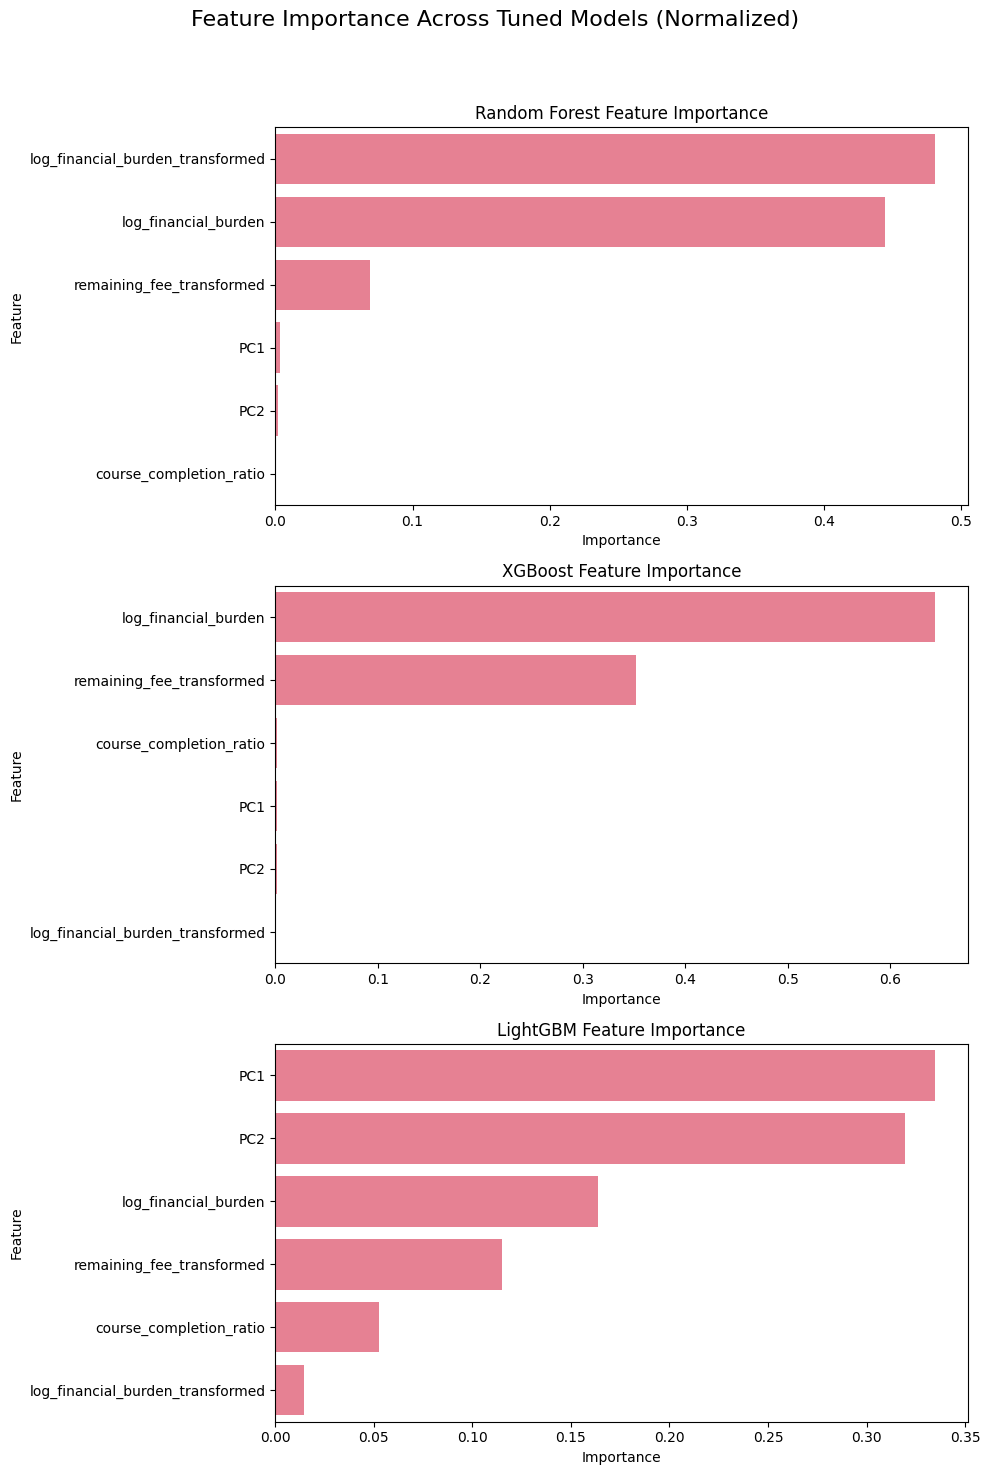

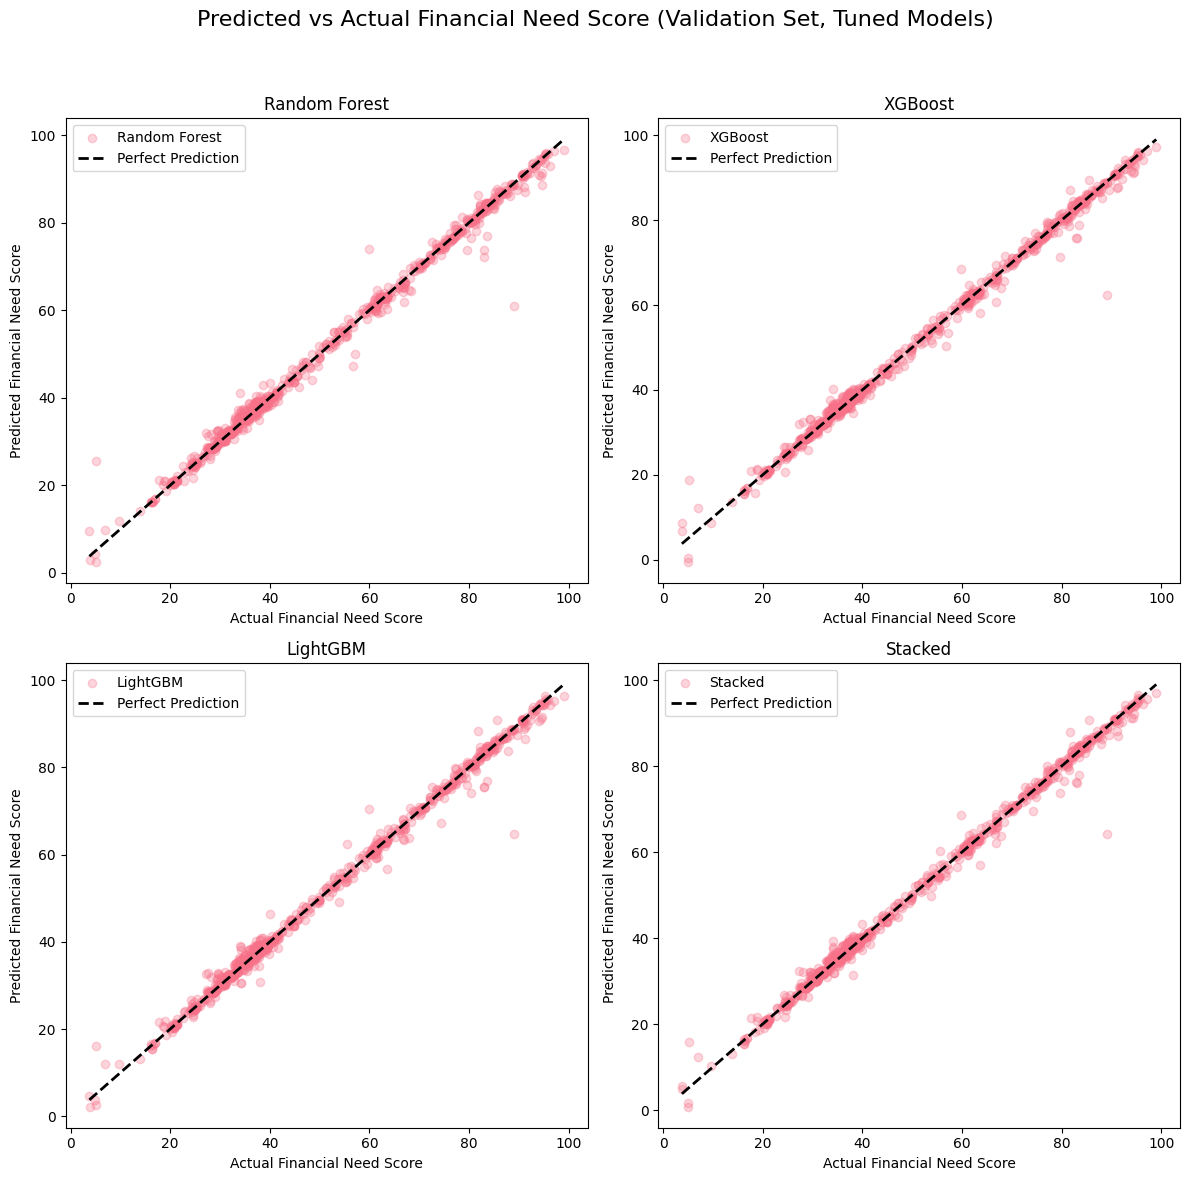

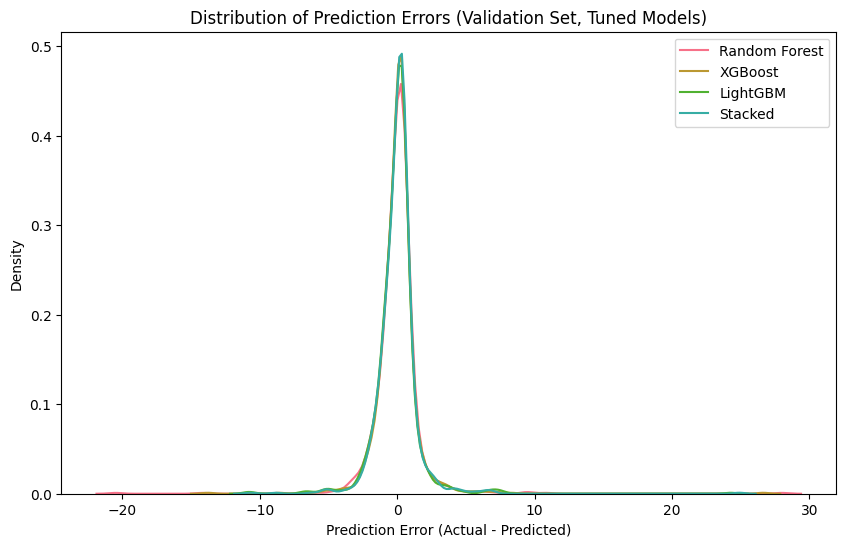

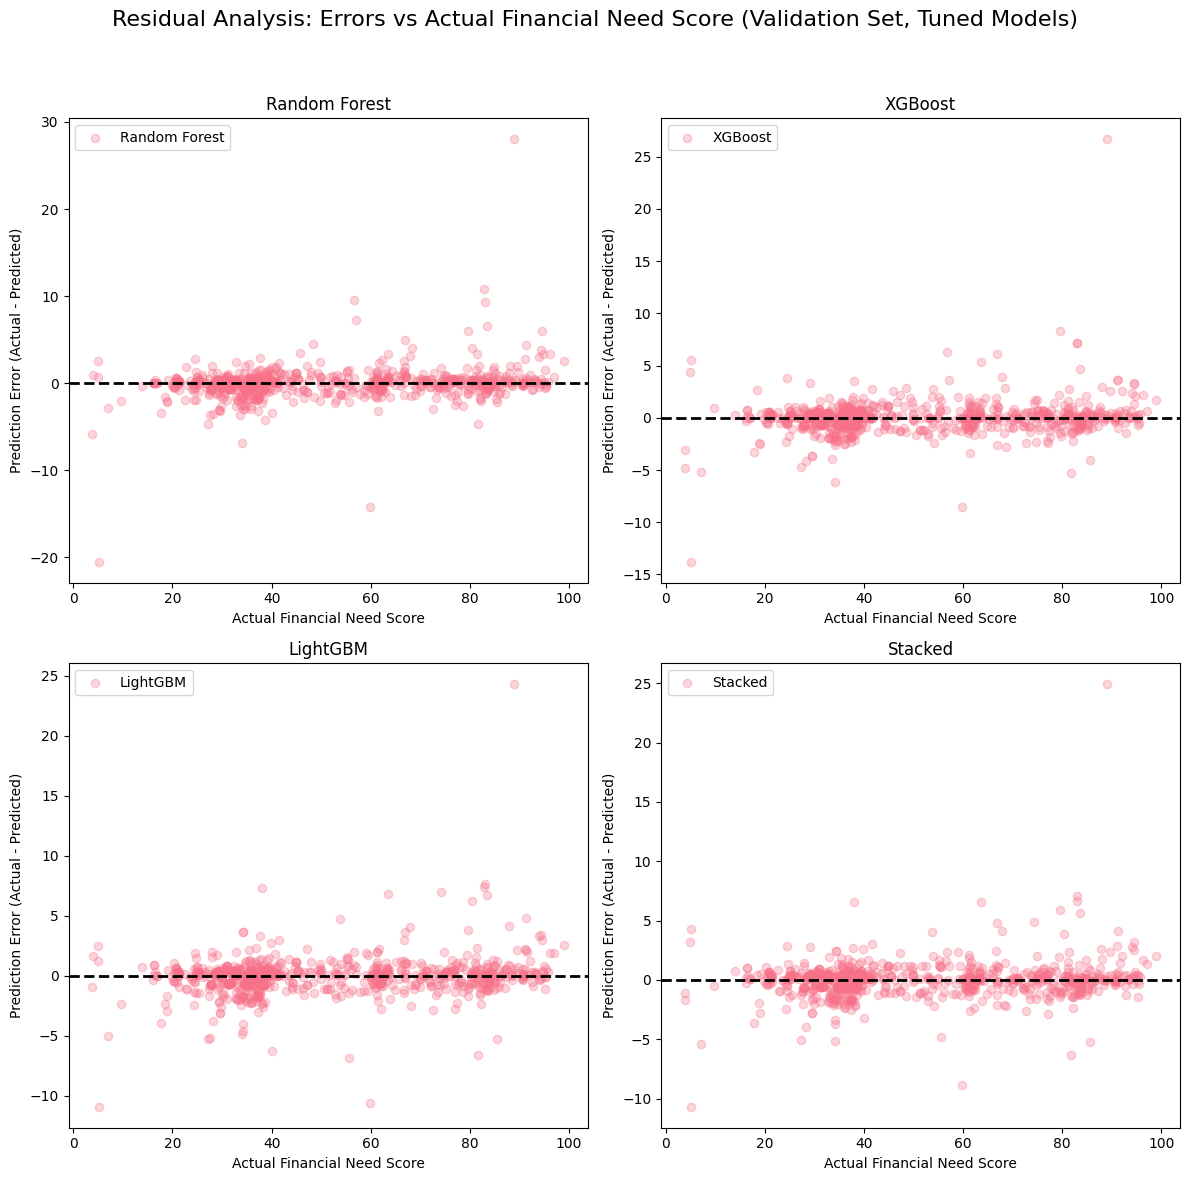

In [17]:
# Step 10: Hyperparameter Tuning
# -----------------------------------------------

import optuna

# Define objective functions for Optuna with expanded parameter ranges
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),  # Expanded range
        'max_depth': trial.suggest_int('max_depth', 5, 30),  # Expanded range
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),  # Allow smaller leaves
        'random_state': 42
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train_np_selected, y_train_np)
    preds = model.predict(X_val_np_selected)
    return mean_absolute_error(y_val_np, preds)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),  # Expanded range
        'max_depth': trial.suggest_int('max_depth', 3, 15),  # Expanded range
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),  # Expanded range
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # Slightly expanded
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train_np_selected, y_train_np)
    preds = model.predict(X_val_np_selected)
    return mean_absolute_error(y_val_np, preds)

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),  # Expanded range
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),  # Expanded range
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),  # Expanded range
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),  # Slightly expanded
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # Slightly expanded
        'random_state': 42
    }
    model = LGBMRegressor(**params)
    model.fit(X_train_np_selected, y_train_np)
    preds = model.predict(X_val_np_selected)
    return mean_absolute_error(y_val_np, preds)

# Optimize hyperparameters using Optuna
print("\n=== Tuning Random Forest ===")
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=50)
best_rf_params = study_rf.best_params
print("Best Random Forest Params:", best_rf_params)

print("\n=== Tuning XGBoost ===")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)
best_xgb_params = study_xgb.best_params
print("Best XGBoost Params:", best_xgb_params)

print("\n=== Tuning LightGBM ===")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=50)
best_lgb_params = study_lgb.best_params
print("Best LightGBM Params:", best_lgb_params)

# Train final models with best parameters
best_rf_model = RandomForestRegressor(**best_rf_params, random_state=42)
best_xgb_model = XGBRegressor(**best_xgb_params, random_state=42)
best_lgb_model = LGBMRegressor(**best_lgb_params, random_state=42)

best_rf_model.fit(X_train_np_selected, y_train_np)
best_xgb_model.fit(X_train_np_selected, y_train_np)
best_lgb_model.fit(X_train_np_selected, y_train_np)

# Generate out-of-fold predictions for stacking with tuned models
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_oof = np.zeros(len(X_train_np_selected))
xgb_oof = np.zeros(len(X_train_np_selected))
lgb_oof = np.zeros(len(X_train_np_selected))

for train_idx, val_idx in kf.split(X_train_np_selected):
    X_tr, X_val = X_train_np_selected[train_idx], X_train_np_selected[val_idx]
    y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]
    
    best_rf_model.fit(X_tr, y_tr)
    rf_oof[val_idx] = best_rf_model.predict(X_val)
    
    best_xgb_model.fit(X_tr, y_tr)
    xgb_oof[val_idx] = best_xgb_model.predict(X_val)
    
    best_lgb_model.fit(X_tr, y_tr)
    lgb_oof[val_idx] = best_lgb_model.predict(X_val)

# Log variation in out-of-fold predictions
print("\n=== Variation in Out-of-Fold Predictions (Tuned Models) ===")
print(f"RF OOF std: {rf_oof.std():.4f}")
print(f"XGB OOF std: {xgb_oof.std():.4f}")
print(f"LGB OOF std: {lgb_oof.std():.4f}")

# Stack predictions using a meta-learner (Ridge Regression)
meta_features = np.column_stack((rf_oof, xgb_oof, lgb_oof))
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(meta_features, y_train_np)

# Log meta-model coefficients
print("\n=== Meta-Model Coefficients (Ridge, Tuned Models) ===")
print(pd.Series(meta_model.coef_, index=['Random Forest', 'XGBoost', 'LightGBM']))

# Predict on validation set with tuned models
rf_val_pred = best_rf_model.predict(X_val_np_selected)
xgb_val_pred = best_xgb_model.predict(X_val_np_selected)
lgb_val_pred = best_lgb_model.predict(X_val_np_selected)
meta_val_features = np.column_stack((rf_val_pred, xgb_val_pred, lgb_val_pred))
stacked_val_pred = meta_model.predict(meta_val_features)

# Define models dictionary for validation set predictions
models = {
    'Random Forest': rf_val_pred,
    'XGBoost': xgb_val_pred,
    'LightGBM': lgb_val_pred,
    'Stacked': stacked_val_pred
}

# Predict on test set with tuned models
rf_test_pred = best_rf_model.predict(X_test_np_selected)
xgb_test_pred = best_xgb_model.predict(X_test_np_selected)
lgb_test_pred = best_lgb_model.predict(X_test_np_selected)
meta_test_features = np.column_stack((rf_test_pred, xgb_test_pred, lgb_test_pred))
stacked_test_pred = meta_model.predict(meta_test_features)

# Log variation in test set predictions
print("\n=== Variation in Test Set Predictions (Tuned Models) ===")
print(f"RF Test std: {rf_test_pred.std():.4f}")
print(f"XGB Test std: {xgb_test_pred.std():.4f}")
print(f"LGB Test std: {lgb_test_pred.std():.4f}")
print(f"Stacked Test std: {stacked_test_pred.std():.4f}")

# Evaluate on validation set
print("\n=== Validation Set Performance (Tuned Models) ===")
for name, preds in models.items():
    mae = mean_absolute_error(y_val_np, preds)
    r2 = r2_score(y_val_np, preds)
    print(f"{name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Evaluate on test set
print("\n=== Test Set Performance (Tuned Models) ===")
for name, preds in {'Random Forest': rf_test_pred, 'XGBoost': xgb_test_pred, 
                    'LightGBM': lgb_test_pred, 'Stacked': stacked_test_pred}.items():
    mae = mean_absolute_error(y_test_np, preds)
    r2 = r2_score(y_test_np, preds)
    print(f"{name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Feature Importance Analysis with Normalized Scores (Tuned Models)
# Random Forest
rf_importance = pd.DataFrame({'Feature': final_feature_names, 'Importance': best_rf_model.feature_importances_})
rf_importance['Importance'] = rf_importance['Importance'] / rf_importance['Importance'].sum()  # Normalize to 0-1
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

# XGBoost
xgb_importance = pd.DataFrame({'Feature': final_feature_names, 'Importance': best_xgb_model.feature_importances_})
xgb_importance['Importance'] = xgb_importance['Importance'] / xgb_importance['Importance'].sum()  # Normalize to 0-1
xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)

# LightGBM
lgb_importance = pd.DataFrame({'Feature': final_feature_names, 'Importance': best_lgb_model.feature_importances_})
lgb_importance['Importance'] = lgb_importance['Importance'] / lgb_importance['Importance'].sum()  # Normalize to 0-1
lgb_importance = lgb_importance.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('Feature Importance Across Tuned Models (Normalized)', fontsize=16)

# Random Forest
sns.barplot(x='Importance', y='Feature', data=rf_importance, ax=axes[0])
axes[0].set_title('Random Forest Feature Importance')

# XGBoost
sns.barplot(x='Importance', y='Feature', data=xgb_importance, ax=axes[1])
axes[1].set_title('XGBoost Feature Importance')

# LightGBM
sns.barplot(x='Importance', y='Feature', data=lgb_importance, ax=axes[2])
axes[2].set_title('LightGBM Feature Importance')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Visualizations
# 1. Scatter Plot of Predicted vs Actual Values (Validation Set) - Separate subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Predicted vs Actual Financial Need Score (Validation Set, Tuned Models)', fontsize=16)

for ax, (name, preds) in zip(axes.flatten(), models.items()):
    ax.scatter(y_val_np, preds, alpha=0.3, label=name)
    ax.plot([y_val_np.min(), y_val_np.max()], [y_val_np.min(), y_val_np.max()], 'k--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Financial Need Score')
    ax.set_ylabel('Predicted Financial Need Score')
    ax.set_title(name)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Distribution of Prediction Errors (Validation Set) with Residual Analysis
plt.figure(figsize=(10, 6))
for name, preds in models.items():
    errors = y_val_np - preds
    sns.kdeplot(errors, label=name)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Density')
plt.title('Distribution of Prediction Errors (Validation Set, Tuned Models)')
plt.legend()
plt.show()

# Residual Analysis: Plot errors vs actual values
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Residual Analysis: Errors vs Actual Financial Need Score (Validation Set, Tuned Models)', fontsize=16)

for ax, (name, preds) in zip(axes.flatten(), models.items()):
    errors = y_val_np - preds
    ax.scatter(y_val_np, errors, alpha=0.3, label=name)
    ax.axhline(y=0, color='k', linestyle='--', lw=2)
    ax.set_xlabel('Actual Financial Need Score')
    ax.set_ylabel('Prediction Error (Actual - Predicted)')
    ax.set_title(name)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Min predicted_financial_need_score: 0.09180938861139439, Max predicted_financial_need_score: 0.8977040050662539
Total Applied Amount: 15371139.0 KSh, Budget: 6500000 KSh, Budget-to-Applied Ratio: 0.4229
Scaled distribution of predicted_financial_need_score in test set:
count    904.000000
mean       0.495702
std        0.267437
min        0.010000
25%        0.312988
50%        0.362630
75%        0.748115
max        0.990000
Name: predicted_financial_need_score, dtype: float64


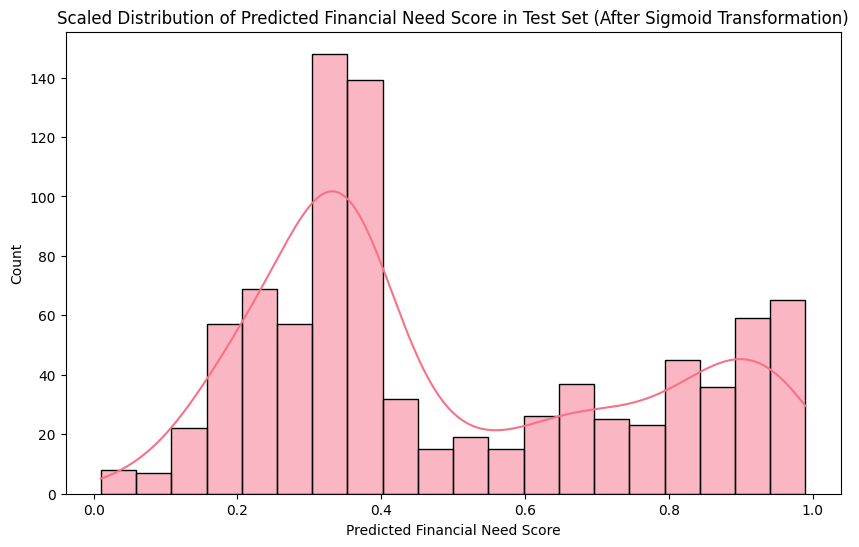

Reward Weights:
allocation_match                      1.0
high_need_bonus                     100.0
high_need_penalty                   -50.0
moderate_need_bonus                  50.0
moderate_need_penalty               -20.0
score_alignment_bonus                10.0
allocation_rate_bonus               500.0
high_need_allocation_rate_bonus     100.0
budget_utilization_bonus           1000.0
allocation_excess_penalty            -5.0
dtype: float64
Episode 0, Total Reward: 272133.53505957866, Allocation Rate: 99.89%, High-Need Allocation Rate: 100.00%, Non-High-Need Allocation Rate: 99.82%, Budget Utilization: 100.00%, Avg High-Need Allocation: 11884.52 KSh, Avg Non-High-Need Allocation: 4232.22 KSh, Epsilon: 0.8955, Episode Time: 0.39 seconds
Episode 100, Total Reward: 272653.35837826005, Allocation Rate: 99.89%, High-Need Allocation Rate: 100.00%, Non-High-Need Allocation Rate: 99.82%, Budget Utilization: 100.00%, Avg High-Need Allocation: 11884.52 KSh, Avg Non-High-Need Allocation: 42

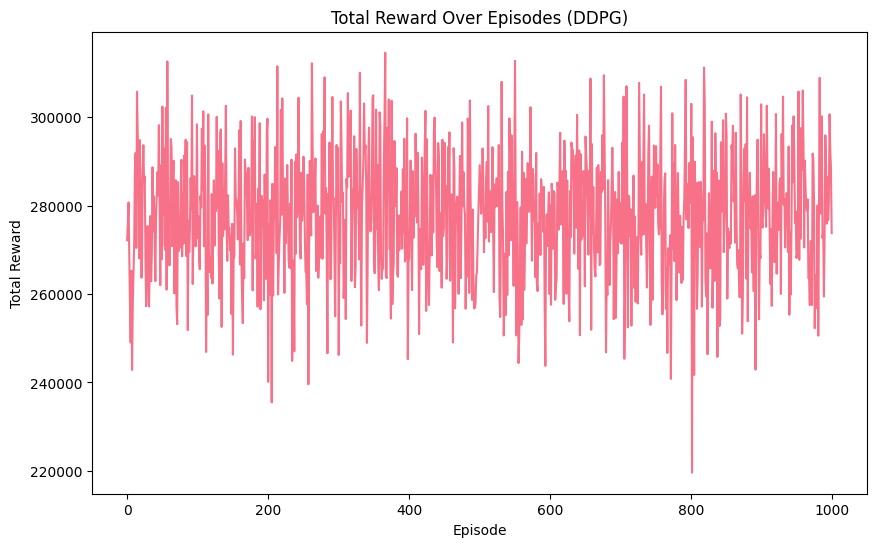

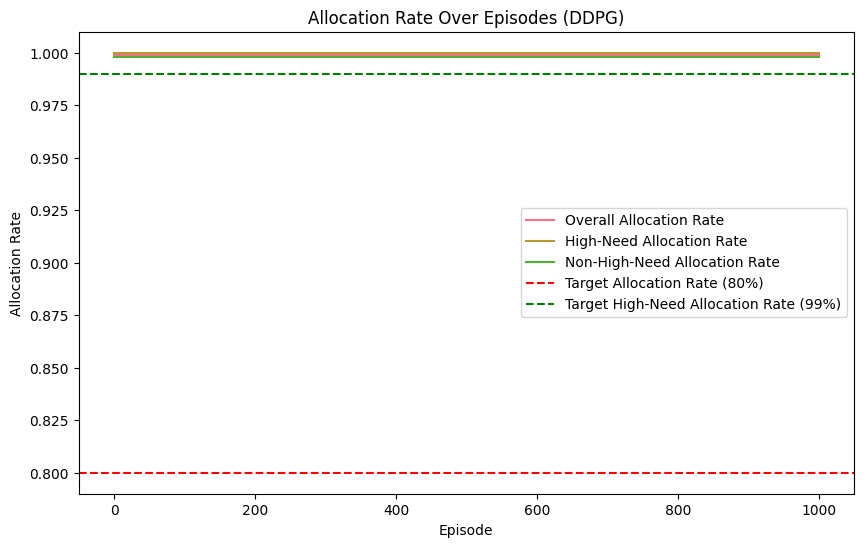

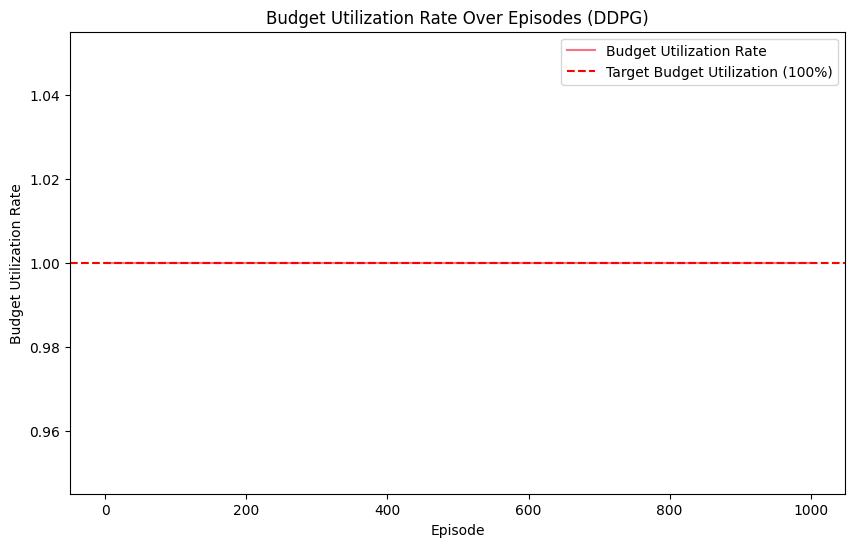

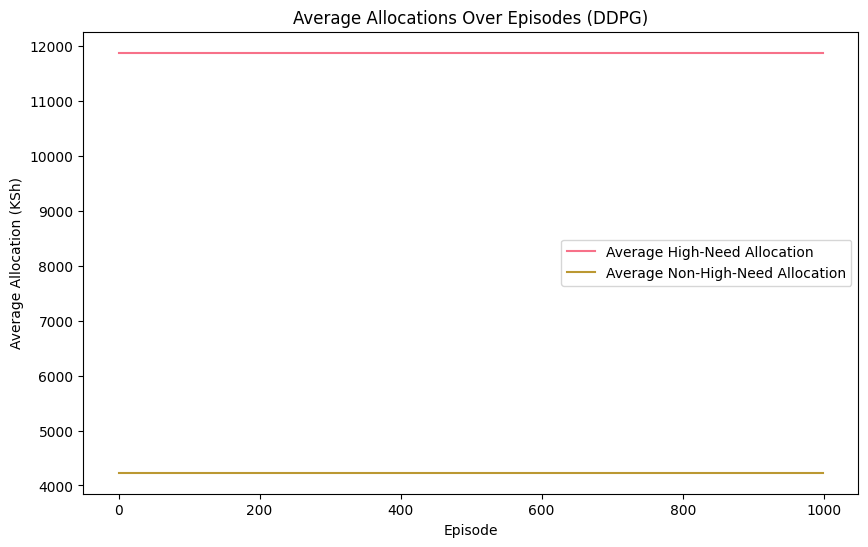

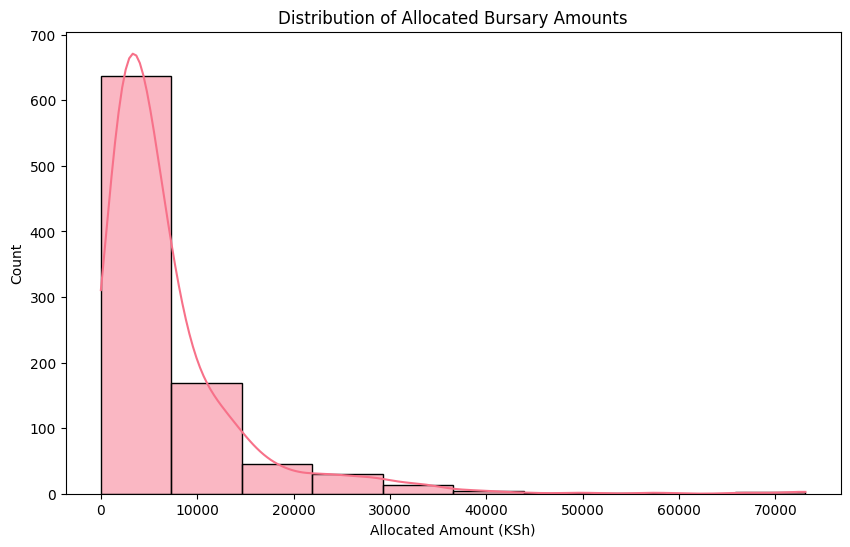

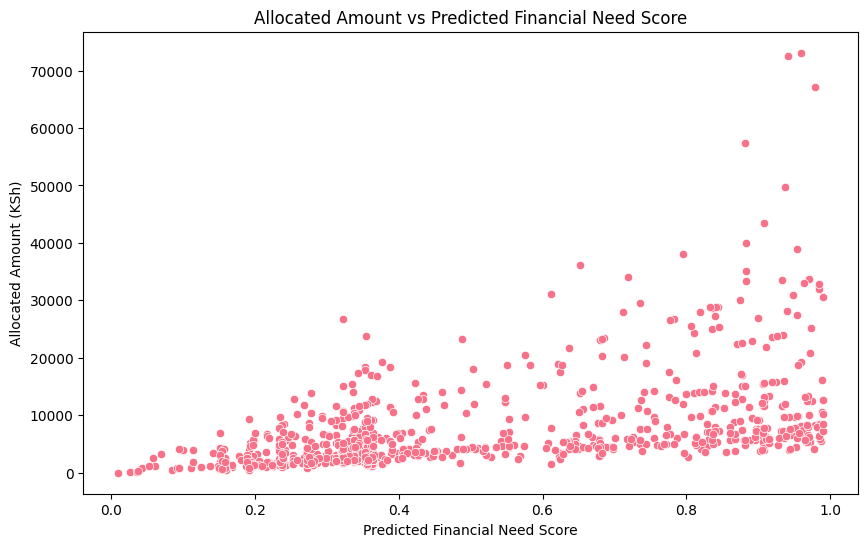


=== Allocation Summary ===
Total Budget: KSh 6500000
Total Allocated: KSh 6500000.0
Remaining Budget: KSh 0.0
Budget Utilization: 100.00%
Highest Allocated Amount: KSh 73106.7890625
Total Number of Students Allocated: 903
Total Applied Amount: KSh 15371139.0
Difference (Allocated - Applied): KSh -8871139.0
Average Amount Allocated per Student (for Allocated Students): KSh 7198.23

Available columns in test_data: ['PC1', 'PC2', 'log_financial_burden', 'remaining_fee_transformed', 'log_financial_burden_transformed', 'course_completion_ratio', 'financial_need_score', 'predicted_financial_need_score', 'amt_applied', 'amt_applied_normalized', 'allocated_amount']

Sample of Allocations:
   predicted_financial_need_score  course_completion_ratio  amt_applied  \
0                        0.252863                 0.461538      10000.0   
1                        0.322138                 0.538462      40000.0   
2                        0.298774                 0.538462      12000.0   
3        

In [18]:
import torch.optim as optim

# Step 11: Reinforcement Learning for Dynamic Allocation with Optimized DDPG (CPU Version)
# -----------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random
import time  # For timing performance

# Step 11.1: Prepare State Space for RL
scaler = MinMaxScaler()

# Use the test set predictions from Step 10 as the financial need score
test_predictions = stacked_test_pred  # From Step 10
test_data = pd.DataFrame(X_test_np_selected, columns=final_feature_names)
test_data['financial_need_score'] = y_test_np
test_data['predicted_financial_need_score'] = test_predictions

def normalize_scores(values, lower=0.01, upper=0.99):
    scores = np.asarray(values, dtype=np.float64)
    scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
    min_score = scores.min()
    max_score = scores.max()
    if max_score > min_score:
        scores = (scores - min_score) / (max_score - min_score)
        return np.clip(scores, lower, upper)
    return np.full(scores.shape, (lower + upper) / 2)

# Standardize and normalize predicted scores for RL allocation. If the stacked model saturates
# near 0.99, fall back to the engineered financial_need_score distribution so allocation
# still reflects applicant-level variation.
raw_predicted_scores = np.nan_to_num(test_data['predicted_financial_need_score'].values, nan=0.0)
raw_predicted_scores = np.clip(raw_predicted_scores, 0, 1)
model_score_std = float(np.std(raw_predicted_scores))
model_cap_ratio = float(np.mean(raw_predicted_scores >= 0.98))
print(f"Raw model score std: {model_score_std:.6f}, cap ratio: {model_cap_ratio:.2f}")
if model_score_std < 0.001 or model_cap_ratio > 0.5:
    print("Stacked model scores are saturated; using engineered financial_need_score distribution for RL allocation.")
    test_data['predicted_financial_need_score'] = normalize_scores(test_data['financial_need_score'].values)
else:
    scaled_model_scores = StandardScaler().fit_transform(raw_predicted_scores.reshape(-1, 1)).flatten()
    test_data['predicted_financial_need_score'] = normalize_scores(expit(scaled_model_scores))

# Retrieve allocation context from data_final for the test set indices
test_indices = y_test.index
test_data['amt_applied'] = data_final.loc[test_indices, 'amt_applied'].values
test_data['vulnerability_score'] = data_final.loc[test_indices, 'vulnerability_score'].values
for pc_feature in ['PC1', 'PC2', 'PC3', 'PC4']:
    test_data[pc_feature] = data_final.loc[test_indices, pc_feature].values

# Thesis-aligned DDPG state: need, vulnerability, requested amount, and PCA context
state_features = [
    'predicted_financial_need_score',
    'vulnerability_score',
    'amt_applied',
    'PC1',
    'PC2',
    'PC3',
    'PC4'
]
state_data = scaler.fit_transform(test_data[state_features])
state_space = pd.DataFrame(state_data, columns=state_features, index=test_data.index)

# Convert state_space and allocation context to NumPy arrays for faster access
state_space_np = state_data
amt_applied_np = test_data['amt_applied'].values
need_scores_np = test_data['predicted_financial_need_score'].values

# Calculate total applied amount and budget-to-applied ratio
total_applied_amount = np.sum(amt_applied_np)
budget = 6_500_000
budget_to_applied_ratio = budget / total_applied_amount if total_applied_amount > 0 else 1.0
print(f"Total Applied Amount: {total_applied_amount} KSh, Budget: {budget} KSh, Budget-to-Applied Ratio: {budget_to_applied_ratio:.4f}")

# Display scaled distribution of predicted_financial_need_score in test set
print("Scaled distribution of predicted_financial_need_score in test set:")
print(test_data['predicted_financial_need_score'].describe())

# Visualize the transformed distribution
plt.figure(figsize=(10, 6))
sns.histplot(test_data['predicted_financial_need_score'], bins=20, kde=True)
plt.title('Scaled Distribution of Predicted Financial Need Score in Test Set (After Sigmoid Transformation)')
plt.xlabel('Predicted Financial Need Score')
plt.ylabel('Count')
plt.show()

# Step 11.1.1: Define Reward Weights (Rebalanced)
reward_weights = {
    'allocation_match': 1.0,
    'high_need_bonus': 100.0,  # Increased to reward high-need allocations
    'high_need_penalty': -50.0,  # Reduced to prevent dominance
    'moderate_need_bonus': 50.0,  # Increased to reward moderate-need allocations
    'moderate_need_penalty': -20.0,  # Reduced to prevent dominance
    'score_alignment_bonus': 10.0,  # Increased to reward alignment
    'allocation_rate_bonus': 500.0,  # Reduced to balance
    'high_need_allocation_rate_bonus': 100.0,  # Reduced to balance
    'budget_utilization_bonus': 1000.0,  # Reduced to balance
    'allocation_excess_penalty': -5.0  # Reduced to prevent dominance
}
print("Reward Weights:")
print(pd.Series(reward_weights))

def compute_reward_features(need_score, normalized_allocation, allocation, applied_amount, remaining_budget, budget, 
                           allocation_rate, high_need_allocation_rate, current_idx, total_students):
    features = {}
    # Reward for matching allocation to need score
    features['allocation_match'] = -abs(need_score - normalized_allocation)
    # Bonuses for high-need students
    features['high_need_bonus'] = 1 if need_score > 0.9 and allocation >= 0.3 * applied_amount and allocation <= applied_amount else 0
    # Penalty for zero allocations to high-need students
    features['high_need_penalty'] = 1 if need_score > 0.5 and allocation == 0 else 0
    # Bonus for moderate-need students
    features['moderate_need_bonus'] = 1 if 0.5 < need_score <= 0.9 and allocation >= 0.2 * applied_amount and allocation <= applied_amount else 0
    # Penalty for low allocations to moderate-need students
    features['moderate_need_penalty'] = 1 if 0.5 < need_score <= 0.9 and allocation < 0.1 * applied_amount else 0
    # Alignment of allocation with need score
    allocation_ratio = allocation / applied_amount if applied_amount > 0 else 0
    features['score_alignment_bonus'] = need_score * allocation_ratio
    # Bonus for achieving high allocation rate (stronger penalty below 80%)
    features['allocation_rate_bonus'] = 1 if allocation_rate >= 0.8 else (allocation_rate - 0.8) * 50  # Reduced penalty factor
    # Bonus for achieving high allocation rate among high-need students
    features['high_need_allocation_rate_bonus'] = 1 if high_need_allocation_rate >= 0.99 else (high_need_allocation_rate - 0.99) * 10  # Reduced penalty factor
    # Reward for budget utilization
    budget_utilization_ratio = (budget - remaining_budget) / budget if budget > 0 else 0
    features['budget_utilization_bonus'] = budget_utilization_ratio
    # Penalty for excessive allocations (to encourage distribution)
    features['allocation_excess_penalty'] = (allocation / applied_amount - 0.5) if allocation > 0.5 * applied_amount else 0
    return features

# Step 11.2: Define RL Environment
class BursaryAllocationEnv:
    def __init__(self, state_space_np, amt_applied_np, need_scores_np, budget=6_500_000):
        self.state_space_np = state_space_np
        self.amt_applied_np = amt_applied_np
        self.need_scores_np = need_scores_np
        self.budget = budget
        self.current_idx = 0
        self.remaining_budget = budget
        self.allocations = np.zeros(len(state_space_np), dtype=np.float32)
        self.min_allocation = 10
        self.state_dim = state_space_np.shape[1]
        self.action_dim = 1
        self.total_students = len(state_space_np)
        self.max_applied = np.max(amt_applied_np)
        self.reward_weights = reward_weights
        self.high_need_students = np.sum(need_scores_np > 0.5)
        self.non_high_need_students = np.sum(need_scores_np <= 0.5)
        self.indices = np.arange(self.total_students)
        # Running counters for allocation rates
        self.allocated_students = 0
        self.high_need_allocated = 0
        self.non_high_need_allocated = 0
        # Budget-to-applied ratio
        self.budget_to_applied_ratio = budget_to_applied_ratio

    def reset(self):
        self.current_idx = 0
        self.remaining_budget = self.budget
        self.allocations = np.zeros(len(self.state_space_np), dtype=np.float32)
        # Reset running counters
        self.allocated_students = 0
        self.high_need_allocated = 0
        self.non_high_need_allocated = 0
        # Shuffle indices for each episode to prevent order bias
        np.random.shuffle(self.indices)
        return self.state_space_np[self.indices[self.current_idx]]

    def step(self, action):
        idx = self.indices[self.current_idx]
        need_score = self.need_scores_np[idx]
        applied_amount = self.amt_applied_np[idx]
        already_allocated = self.allocations[idx]
        remaining_applied = max(0, applied_amount - already_allocated)

        if self.remaining_budget <= 0:
            allocation = 0
            done = True
        else:
            policy_action = float(np.ravel(action)[0]) if action is not None else 1.0
            policy_action = np.clip(policy_action, 0, 1)
            adjusted_percentage = self.budget_to_applied_ratio * need_score * policy_action
            adjusted_percentage = np.clip(adjusted_percentage, 0, 1)
            
            allocation = int(remaining_applied * adjusted_percentage)
            if allocation > 0:
                allocation = max(allocation, self.min_allocation)
            # Hard cap at applied amount
            allocation = min(allocation, remaining_applied)
            if allocation > self.remaining_budget:
                allocation = min(allocation, self.remaining_budget, remaining_applied, self.min_allocation)
                done = False if self.remaining_budget > 0 else True
            else:
                done = False

        # Update running counters
        if allocation > 0 and self.allocations[idx] == 0:
            self.allocated_students += 1
            if need_score > 0.5:
                self.high_need_allocated += 1
            else:
                self.non_high_need_allocated += 1

        self.remaining_budget -= allocation
        self.allocations[idx] += allocation

        # Calculate allocation rates using running counters
        allocation_rate = self.allocated_students / (self.current_idx + 1) if self.current_idx + 1 > 0 else 0
        high_need_allocation_rate = self.high_need_allocated / self.high_need_students if self.high_need_students > 0 else 0
        reward_features = compute_reward_features(need_score, allocation / self.max_applied if self.max_applied > 0 else 0, 
                                                 allocation, applied_amount, self.remaining_budget, self.budget, 
                                                 allocation_rate, high_need_allocation_rate, 
                                                 self.current_idx, self.total_students)
        reward = sum(self.reward_weights[feature] * value for feature, value in reward_features.items())
        # Additional penalties and bonuses
        if self.allocations[idx] > applied_amount:
            reward -= 10  # Reduced penalty
        if allocation > 0:
            reward += 20
        if self.remaining_budget < 0:
            self.remaining_budget = 0
            reward -= 10
        self.current_idx += 1
        done = done or self.remaining_budget <= 0 or self.current_idx >= len(self.state_space_np)

        # Post-allocation adjustment: Redistribute remaining budget proportionally
        if done and self.remaining_budget > 0:
            initial_total_allocated = np.sum(self.allocations)
            if initial_total_allocated > 0:
                # Scale up allocations proportionally to use the full budget
                scaling_factor = self.budget / initial_total_allocated
                self.allocations *= scaling_factor
                # Cap at applied amounts
                for i in range(self.total_students):
                    self.allocations[i] = min(self.allocations[i], self.amt_applied_np[i])
                # Recalculate total allocated after capping
                total_allocated_after_scaling = np.sum(self.allocations)
                self.remaining_budget = self.budget - total_allocated_after_scaling

                # Distribute any remaining budget to high-need students
                if self.remaining_budget > 0:
                    high_need_indices = [i for i in range(self.total_students) if self.need_scores_np[i] > 0.5 and self.allocations[i] < self.amt_applied_np[i]]
                    if high_need_indices:
                        high_need_sorted = sorted(high_need_indices, key=lambda i: self.need_scores_np[i], reverse=True)
                        remaining_to_distribute = self.remaining_budget
                        for i in high_need_sorted:
                            if remaining_to_distribute <= 0:
                                break
                            remaining_applied = max(0, self.amt_applied_np[i] - self.allocations[i])
                            additional_allocation = min(remaining_to_distribute, remaining_applied)
                            self.allocations[i] += additional_allocation
                            remaining_to_distribute -= additional_allocation
                        self.remaining_budget = remaining_to_distribute

        next_state = self.state_space_np[self.indices[self.current_idx]] if not done else np.zeros(self.state_dim)
        return next_state, reward, done, {}

# Step 11.3: DDPG Implementation
# Actor Network (Enhanced)
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.layer1 = nn.Linear(state_dim, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = F.relu(self.layer1(state))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = torch.tanh(self.layer4(x))
        return self.max_action * x

# Critic Network (Enhanced)
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.layer1 = nn.Linear(state_dim + action_dim, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

# DDPG Agent (Updated)
class DDPGAgent:
    def __init__(self, state_dim, action_dim, max_action):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.max_action = max_action
        self.actor = Actor(state_dim, action_dim, max_action)
        self.actor_target = Actor(state_dim, action_dim, max_action)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=5e-5)
        self.critic = Critic(state_dim, action_dim)
        self.critic_target = Critic(state_dim, action_dim)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=5e-4)
        self.replay_buffer = deque(maxlen=100000)
        self.gamma = 0.99
        self.tau = 0.0005
        self.batch_size = 64
        self.epsilon = 0.9
        self.epsilon_decay = 0.995
        self.min_epsilon = 0.01
        self.train_frequency = 100

    def select_action(self, state, training=True):
        state = torch.FloatTensor(state)
        action = self.actor(state).detach().numpy()
        need_score = state[0].item()
        if need_score > 0.5:
            action = np.clip(action, 0.3, 1)
        else:
            action = np.clip(action, 0.2, 1)
        if training:
            noise = np.random.normal(0, 0.001, self.action_dim)
            action = action + noise
        return np.clip(action, 0, 1)

    def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return
        batch = random.sample(self.replay_buffer, self.batch_size)
        state, action, reward, next_state, done = zip(*batch)
        state = torch.FloatTensor(state)
        action = torch.FloatTensor(action)
        reward = torch.FloatTensor(reward)
        next_state = torch.FloatTensor(next_state)
        done = torch.FloatTensor(done)
        target_q = self.critic_target(next_state, self.actor_target(next_state))
        target_q = reward + (1 - done) * self.gamma * target_q
        current_q = self.critic(state, action)
        critic_loss = F.mse_loss(current_q, target_q.detach())
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        actor_loss = -self.critic(state, self.actor(state)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

    def add_to_replay_buffer(self, state, action, reward, next_state, done):
        self.replay_buffer.append((state, action, reward, next_state, done))

# Train DDPG Agent
env = BursaryAllocationEnv(state_space_np, amt_applied_np, need_scores_np)
agent = DDPGAgent(state_dim=env.state_dim, action_dim=env.action_dim, max_action=1.0)

episodes = 1000
rewards = []
allocation_rates = []
high_need_allocation_rates = []
budget_utilization_rates = []
high_need_avg_allocations = []
non_high_need_allocation_rates = []
non_high_need_avg_allocations = []
steps = 0

for episode in range(episodes):
    episode_start_time = time.time()
    state = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = agent.select_action(state, training=True)
        next_state, reward, done, _ = env.step(action)
        agent.add_to_replay_buffer(state, action, reward, next_state, done)
        steps += 1
        if steps % agent.train_frequency == 0:
            agent.train()
        state = next_state
        total_reward += reward
    if not done and env.remaining_budget > 0:
        under_utilization_ratio = env.remaining_budget / env.budget
        total_reward -= under_utilization_ratio * 50  # Reduced penalty
    rewards.append(total_reward)
    # Calculate allocation rate for this episode
    allocation_rate = env.allocated_students / env.total_students
    allocation_rates.append(allocation_rate)
    # Calculate allocation rate for high-need students (need_score > 0.5)
    high_need_allocation_rate = env.high_need_allocated / env.high_need_students if env.high_need_students > 0 else 0
    high_need_allocation_rates.append(high_need_allocation_rate)
    # Calculate allocation rate for non-high-need students (need_score ≤ 0.5)
    non_high_need_allocation_rate = env.non_high_need_allocated / env.non_high_need_students if env.non_high_need_students > 0 else 0
    non_high_need_allocation_rates.append(non_high_need_allocation_rate)
    # Calculate budget utilization rate
    budget_utilization_rate = (env.budget - env.remaining_budget) / env.budget
    budget_utilization_rates.append(budget_utilization_rate)
    # Calculate average allocation for high-need and non-high-need students
    high_need_allocs = [alloc for idx, alloc in enumerate(env.allocations) if env.need_scores_np[idx] > 0.5 and alloc > 0]
    avg_high_need_alloc = sum(high_need_allocs) / len(high_need_allocs) if high_need_allocs else 0
    high_need_avg_allocations.append(avg_high_need_alloc)
    non_high_need_allocs = [alloc for idx, alloc in enumerate(env.allocations) if env.need_scores_np[idx] <= 0.5 and alloc > 0]
    avg_non_high_need_alloc = sum(non_high_need_allocs) / len(non_high_need_allocs) if non_high_need_allocs else 0
    non_high_need_avg_allocations.append(avg_non_high_need_alloc)
    agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
    if episode % 100 == 0:
        episode_time = time.time() - episode_start_time
        print(f"Episode {episode}, Total Reward: {total_reward}, Allocation Rate: {allocation_rate * 100:.2f}%, High-Need Allocation Rate: {high_need_allocation_rate * 100:.2f}%, Non-High-Need Allocation Rate: {non_high_need_allocation_rate * 100:.2f}%, Budget Utilization: {budget_utilization_rate * 100:.2f}%, Avg High-Need Allocation: {avg_high_need_alloc:.2f} KSh, Avg Non-High-Need Allocation: {avg_non_high_need_alloc:.2f} KSh, Epsilon: {agent.epsilon:.4f}, Episode Time: {episode_time:.2f} seconds")

# Step 11.4: Allocate Bursaries Using Trained Agent
env.reset()
allocations = []
indices = list(range(len(env.state_space_np)))

agent.actor.eval()  # Set to evaluation mode
with torch.no_grad():
    for idx in indices:
        state = env.state_space_np[idx]
        applied_amount = env.amt_applied_np[idx]
        already_allocated = env.allocations[idx]
        remaining_applied = max(0, applied_amount - already_allocated)
        need_score = env.need_scores_np[idx]
        policy_action = float(np.ravel(agent.select_action(state, training=False))[0])
        adjusted_percentage = env.budget_to_applied_ratio * need_score * policy_action
        adjusted_percentage = np.clip(adjusted_percentage, 0, 1)
        allocation = int(remaining_applied * adjusted_percentage)
        if allocation > 0:
            allocation = max(allocation, env.min_allocation)
        # Hard cap at applied amount
        allocation = min(allocation, remaining_applied)
        if allocation > env.remaining_budget:
            allocation = min(allocation, env.remaining_budget, remaining_applied, env.min_allocation)
        env.remaining_budget -= allocation
        env.allocations[idx] += allocation
        allocations.append(allocation)
        if env.remaining_budget <= 0:
            break

    # Post-allocation adjustment: Redistribute remaining budget proportionally
    if env.remaining_budget > 0:
        initial_total_allocated = np.sum(env.allocations)
        if initial_total_allocated > 0:
            # Scale up allocations proportionally to use the full budget
            scaling_factor = env.budget / initial_total_allocated
            env.allocations *= scaling_factor
            allocations = env.allocations.tolist()
            # Cap at applied amounts
            for i in range(len(allocations)):
                allocations[i] = min(allocations[i], env.amt_applied_np[i])
            env.allocations = np.array(allocations)
            # Recalculate total allocated after capping
            total_allocated_after_scaling = np.sum(env.allocations)
            env.remaining_budget = env.budget - total_allocated_after_scaling

            # Distribute any remaining budget to high-need students
            if env.remaining_budget > 0:
                high_need_indices = [i for i in range(len(env.state_space_np)) if env.need_scores_np[i] > 0.5 and env.allocations[i] < env.amt_applied_np[i]]
                if high_need_indices:
                    high_need_sorted = sorted(high_need_indices, key=lambda i: env.need_scores_np[i], reverse=True)
                    remaining_to_distribute = env.remaining_budget
                    for i in high_need_sorted:
                        if remaining_to_distribute <= 0:
                            break
                        remaining_applied = max(0, env.amt_applied_np[i] - env.allocations[i])
                        additional_allocation = min(remaining_to_distribute, remaining_applied)
                        env.allocations[i] += additional_allocation
                        allocations[i] += additional_allocation
                        remaining_to_distribute -= additional_allocation
                    env.remaining_budget = remaining_to_distribute

# Add allocations to test_data
test_data['allocated_amount'] = pd.Series(allocations, index=test_data.index[:len(allocations)])

# Visualizations
plt.figure(figsize=(10, 6))
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward Over Episodes (DDPG)')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(allocation_rates, label='Overall Allocation Rate')
plt.plot(high_need_allocation_rates, label='High-Need Allocation Rate')
plt.plot(non_high_need_allocation_rates, label='Non-High-Need Allocation Rate')
plt.xlabel('Episode')
plt.ylabel('Allocation Rate')
plt.title('Allocation Rate Over Episodes (DDPG)')
plt.axhline(y=0.8, color='r', linestyle='--', label='Target Allocation Rate (80%)')
plt.axhline(y=0.99, color='g', linestyle='--', label='Target High-Need Allocation Rate (99%)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(budget_utilization_rates, label='Budget Utilization Rate')
plt.xlabel('Episode')
plt.ylabel('Budget Utilization Rate')
plt.title('Budget Utilization Rate Over Episodes (DDPG)')
plt.axhline(y=1.0, color='r', linestyle='--', label='Target Budget Utilization (100%)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(high_need_avg_allocations, label='Average High-Need Allocation')
plt.plot(non_high_need_avg_allocations, label='Average Non-High-Need Allocation')
plt.xlabel('Episode')
plt.ylabel('Average Allocation (KSh)')
plt.title('Average Allocations Over Episodes (DDPG)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(test_data['allocated_amount'], bins=10, kde=True)
plt.xlabel('Allocated Amount (KSh)')
plt.ylabel('Count')
plt.title('Distribution of Allocated Bursary Amounts')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='predicted_financial_need_score', y='allocated_amount', data=test_data)
plt.xlabel('Predicted Financial Need Score')
plt.ylabel('Allocated Amount (KSh)')
plt.title('Allocated Amount vs Predicted Financial Need Score')
plt.show()

# Summary of Allocations
total_applied = test_data['amt_applied'].sum()
total_allocated = sum(allocations)
difference = total_allocated - total_applied
num_allocated_students = sum(1 for alloc in allocations if alloc > 0)
average_allocated_per_student = total_allocated / num_allocated_students if num_allocated_students > 0 else 0

print("\n=== Allocation Summary ===")
print(f"Total Budget: KSh {env.budget}")
print(f"Total Allocated: KSh {total_allocated}")
print(f"Remaining Budget: KSh {env.remaining_budget}")
print(f"Budget Utilization: {(total_allocated / env.budget) * 100:.2f}%")
print(f"Highest Allocated Amount: KSh {max(allocations) if allocations else 0}")
print(f"Total Number of Students Allocated: {num_allocated_students}")
print(f"Total Applied Amount: KSh {total_applied}")
print(f"Difference (Allocated - Applied): KSh {difference}")
print(f"Average Amount Allocated per Student (for Allocated Students): KSh {average_allocated_per_student:.2f}")

print("\nAvailable columns in test_data:", test_data.columns.tolist())

columns_to_display = ['predicted_financial_need_score', 'course_completion_ratio', 
                      'acad_perf_Good', 'past_support_impact', 'amt_applied', 'allocated_amount']
existing_columns = [col for col in columns_to_display if col in test_data.columns]

print("\nSample of Allocations:")
print(test_data[existing_columns].head(10))



In [ ]:
#test_data.to_csv('test data.csv', index=False)

Shape of X_val_np_selected: (903, 6)
Shape of X_test_np_selected: (904, 6)
Columns in test_data: ['PC1', 'PC2', 'log_financial_burden', 'remaining_fee_transformed', 'log_financial_burden_transformed', 'course_completion_ratio', 'financial_need_score', 'predicted_financial_need_score', 'amt_applied', 'amt_applied_normalized', 'allocated_amount']


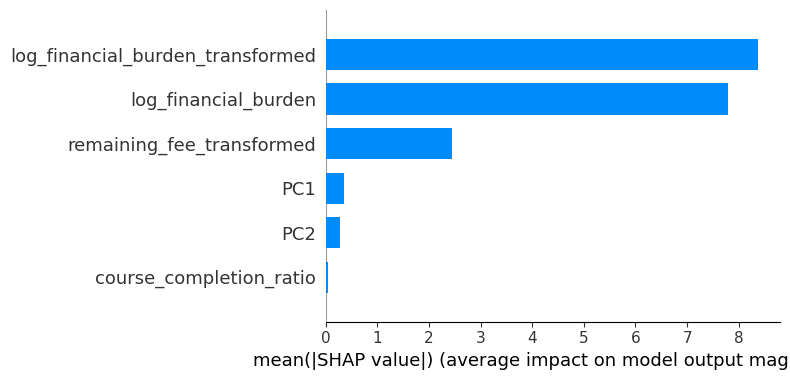

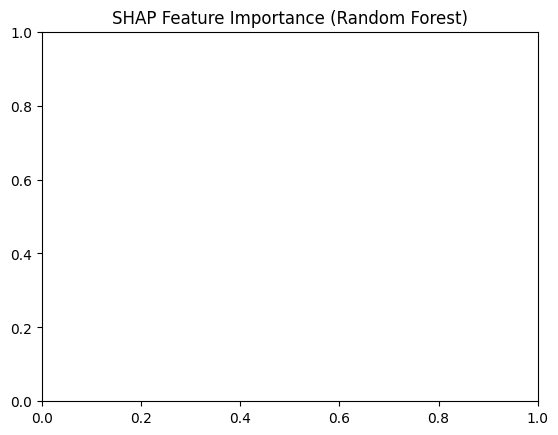

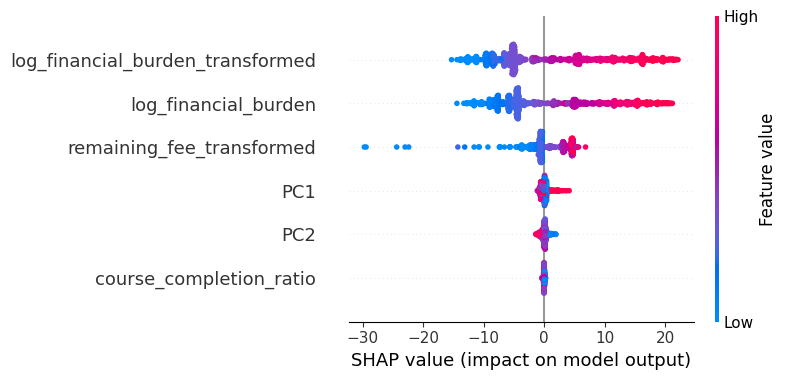

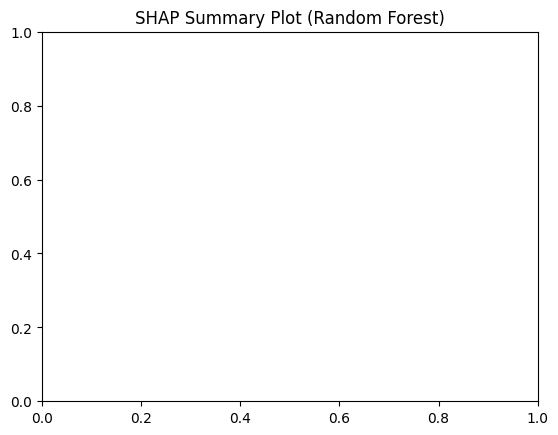

AttributeError: 'BursaryAllocationEnv' object has no attribute 'state_space'

In [19]:
# Step 12: Explainability for Supervised Learning and RL
# -----------------------------------------------

import shap

# Debug: Verify shapes and columns
print("Shape of X_val_np_selected:", X_val_np_selected.shape)
print("Shape of X_test_np_selected:", X_test_np_selected.shape)
print("Columns in test_data:", test_data.columns.tolist())

# Create a DataFrame for X_val with correct feature names from final_feature_names (from Step 9)
X_val_df = pd.DataFrame(X_val_np_selected, columns=final_feature_names)

# Step 12.1: Explainability for Supervised Learning (SHAP)
# Use the tuned Random Forest model (best_rf_model from Step 10)
try:
    explainer = shap.TreeExplainer(best_rf_model)
except Exception as e:
    print(f"TreeExplainer failed: {e}. Using KernelExplainer instead.")
    explainer = shap.KernelExplainer(best_rf_model.predict, X_val_np_selected)

shap_values = explainer.shap_values(X_val_np_selected)

# SHAP Summary Plot (Bar)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_df, plot_type="bar", feature_names=X_val_df.columns)
plt.title('SHAP Feature Importance (Random Forest)')
plt.show()

# SHAP Summary Plot (Detailed)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_df, feature_names=X_val_df.columns)
plt.title('SHAP Summary Plot (Random Forest)')
plt.show()

# Step 12.2: Explainability for RL (Log Decisions)
# Log RL decisions with associated rewards using the environment and DDPG agent from Step 11
env.reset()
state = env.state_space.iloc[0].values
rl_explanations = []

# Analyze reward distribution to adjust filter
rewards = []
idx = 0
done = False
while idx < len(env.state_space) and not done:
    if env.remaining_budget <= 0:  # Stop allocating if budget is depleted
        allocation = 0
    else:
        action = agent.select_action(state)  # Use DDPG agent's select_action method
        percentage = np.clip(action[0], 0, 1)  # Ensure action is scalar
        applied_amount = env.amt_applied.iloc[idx]
        already_allocated = env.allocations[idx]
        remaining_applied = max(0, applied_amount - already_allocated)
        allocation = int(remaining_applied * percentage)  # Compute allocation using continuous action
        if allocation > 0:
            allocation = max(allocation, env.min_allocation)  # Ensure minimum allocation
        if allocation > env.remaining_budget:
            allocation = 0
    state, reward, done, _ = env.step(action)
    rewards.append(reward)
    rl_explanations.append({
        'Student Index': idx,
        'Predicted Financial Need Score': env.state_space.iloc[idx]['predicted_financial_need_score'],
        'Allocated Amount': allocation,
        'Reward': reward
    })
    if not done and idx + 1 < len(env.state_space):
        state = env.state_space.iloc[idx + 1].values
    idx += 1

# Log reward distribution
rewards_series = pd.Series(rewards)
print("\nReward Distribution Statistics:")
print(rewards_series.describe())

rl_explanations_df = pd.DataFrame(rl_explanations)
# Adjust the reward filter based on the updated reward distribution
# Assuming the 25th and 75th percentiles for a reasonable range
reward_lower_bound = rewards_series.quantile(0.25)
reward_upper_bound = rewards_series.quantile(0.75)
filtered_rl_explanations_df = rl_explanations_df[
    (rl_explanations_df['Allocated Amount'] >= 10000) & 
    (rl_explanations_df['Allocated Amount'] < 25000) & 
    (rl_explanations_df['Reward'] >= reward_lower_bound) & 
    (rl_explanations_df['Reward'] <= reward_upper_bound)
]

print("Sample RL Explanations (Filtered by Updated Reward Range):")
print(filtered_rl_explanations_df.head(10))

# Visualize RL Decisions
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Predicted Financial Need Score', y='Reward', size='Allocated Amount', hue='Allocated Amount', data=rl_explanations_df)
plt.title('RL Rewards vs Predicted Financial Need Score')
plt.xlabel('Predicted Financial Need Score')
plt.ylabel('Reward')
plt.show()

[LightGBM] [Warning] feature_fraction is set=0.9482280859225611, colsample_bytree=0.8307961622831375 will be ignored. Current value: feature_fraction=0.9482280859225611
Supervised Learning Performance on Test Set:
Random Forest - MAE: 0.8357, R²: 0.9934
XGBoost - MAE: 0.8434, R²: 0.9943
LightGBM - MAE: 0.8202, R²: 0.9963
Stacked - MAE: 0.8088, R²: 0.9962

Fairness Metrics (Mean Allocation by Predicted Financial Need Score):
                                        mean  count  Total Allocated  \
predicted_financial_need_score                                         
(0.00902, 0.206]                 2022.202469     95     1.921092e+05   
(0.206, 0.402]                   4490.197622    408     1.832001e+06   
(0.402, 0.598]                   6813.639965     84     5.723458e+05   
(0.598, 0.794]                  10184.355129    114     1.161016e+06   
(0.794, 0.99]                   13509.990309    203     2.742528e+06   

                                Utilization (%)  
predicted_financi

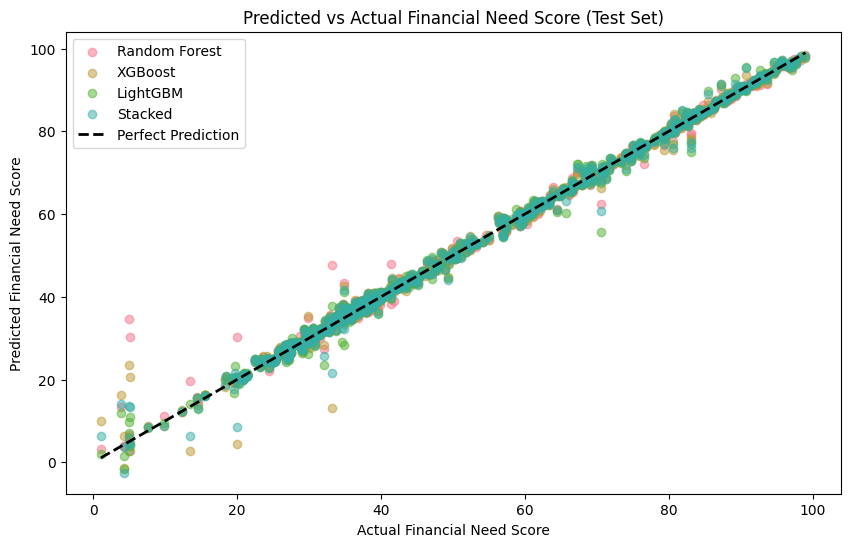

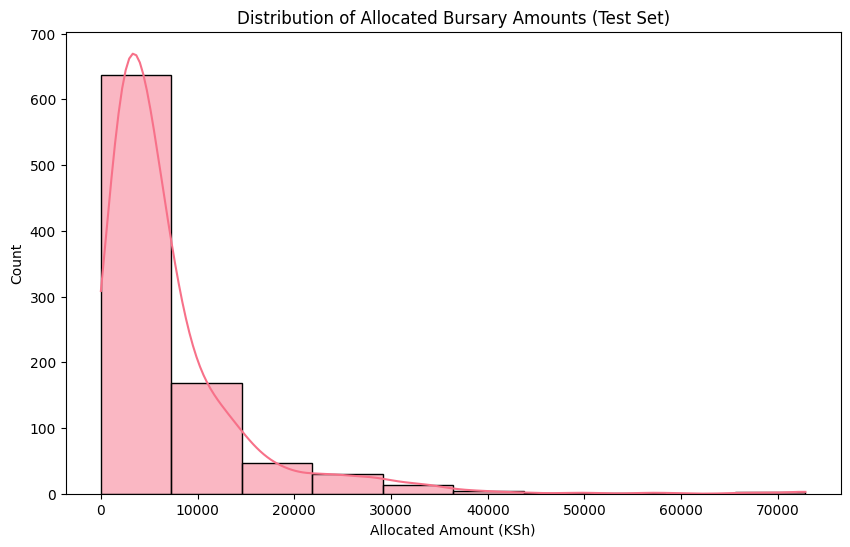

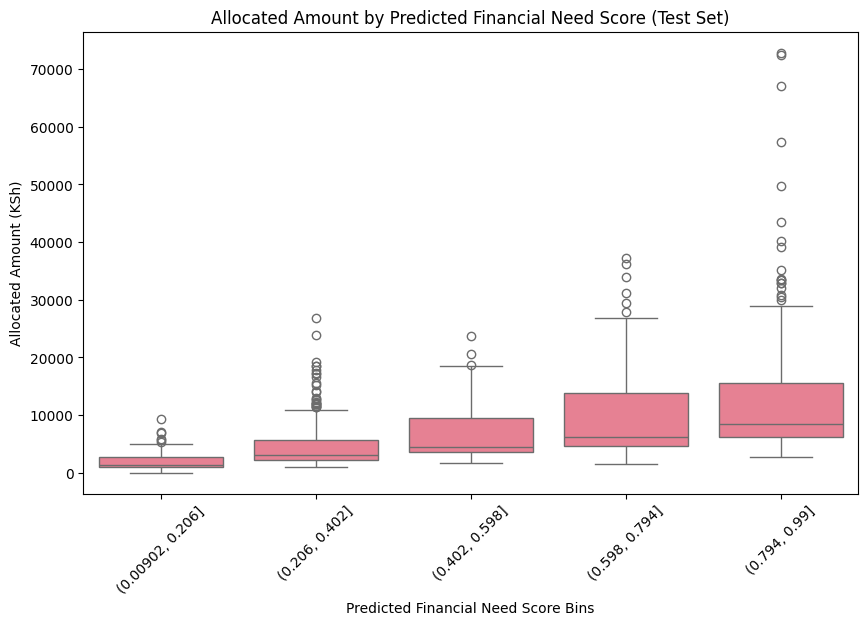

In [ ]:
# Step 13: Evaluation on Test Set
# -----------------------------------------------

# Step 13.1: Evaluate Supervised Learning Models on Test Set
# Predict on test set using tuned models (from Step 10)
rf_test_pred = best_rf_model.predict(X_test_np_selected)
xgb_test_pred = best_xgb_model.predict(X_test_np_selected)
lgb_test_pred = best_lgb_model.predict(X_test_np_selected)
meta_test_features = np.column_stack((rf_test_pred, xgb_test_pred, lgb_test_pred))
stacked_test_pred = meta_model.predict(meta_test_features)

# Evaluate models on test set
models = {
    'Random Forest': rf_test_pred,
    'XGBoost': xgb_test_pred,
    'LightGBM': lgb_test_pred,
    'Stacked': stacked_test_pred
}

print("Supervised Learning Performance on Test Set:")
for name, preds in models.items():
    mae = mean_absolute_error(y_test_np, preds)
    r2 = r2_score(y_test_np, preds)
    print(f"{name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Step 13.2: Evaluate RL Agent on Test Set
# Use the test_state_space and allocations from Step 11
test_results = test_data.copy()

# Step 13.3: Fairness Metrics
# Evaluate fairness by checking allocation distribution across predicted financial need levels
print("\nFairness Metrics (Mean Allocation by Predicted Financial Need Score):")
fairness_metrics = test_results.groupby(pd.cut(test_results['predicted_financial_need_score'], bins=5))['allocated_amount'].agg(['mean', 'count'])
# Calculate total allocated per bin and utilization as a percentage of the total budget
total_budget = 6_500_000  # Updated to match Step 11
fairness_metrics['Total Allocated'] = fairness_metrics['mean'] * fairness_metrics['count']
fairness_metrics['Utilization (%)'] = (fairness_metrics['Total Allocated'] / total_budget) * 100
print(fairness_metrics)

# Step 13.4: Efficiency Metrics
total_allocated = test_results['allocated_amount'].sum()
budget_utilization = (total_allocated / total_budget) * 100

print("\nEfficiency Metrics:")
print(f"Total Allocated Amount: KSh {total_allocated:.2f}")
print(f"Budget Utilization: {budget_utilization:.2f}%")

# Visualizations
# 1. Scatter Plot of Predicted vs Actual Financial Need Score (Test Set)
plt.figure(figsize=(10, 6))
for name, preds in models.items():
    plt.scatter(y_test_np, preds, label=name, alpha=0.5)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Financial Need Score')
plt.ylabel('Predicted Financial Need Score')
plt.title('Predicted vs Actual Financial Need Score (Test Set)')
plt.legend()
plt.show()

# 2. Distribution of Allocated Amounts (Test Set)
plt.figure(figsize=(10, 6))
sns.histplot(test_results['allocated_amount'], bins=10, kde=True)
plt.xlabel('Allocated Amount (KSh)')
plt.ylabel('Count')
plt.title('Distribution of Allocated Bursary Amounts (Test Set)')
plt.show()

# 3. Fairness: Box Plot of Allocated Amount by Predicted Financial Need Score
plt.figure(figsize=(10, 6))
sns.boxplot(x=pd.cut(test_results['predicted_financial_need_score'], bins=5), y='allocated_amount', data=test_results)
plt.xlabel('Predicted Financial Need Score Bins')
plt.ylabel('Allocated Amount (KSh)')
plt.title('Allocated Amount by Predicted Financial Need Score (Test Set)')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Step 14: Model Serialization, Fairness, Transparency
# -----------------------------------------------

import joblib
from datetime import datetime


# Step 14.1: Model Serialization
# Save the supervised learning models
joblib.dump(best_rf_model, 'rf_model_tuned.joblib')
joblib.dump(best_xgb_model, 'xgb_model_tuned.joblib')
joblib.dump(best_lgb_model, 'lgb_model_tuned.joblib')
joblib.dump(meta_model, 'meta_model_tuned.joblib')
joblib.dump(final_feature_names, 'final_feature_names.joblib')

# Save the DDPG agent (actor and critic networks, and other parameters)
torch.save(agent.actor.state_dict(), 'ddpg_actor.pth')
torch.save(agent.critic.state_dict(), 'ddpg_critic.pth')
rl_agent_data = {
    'state_dim': agent.state_dim,
    'action_dim': agent.action_dim,
    'max_action': agent.max_action,
    'gamma': agent.gamma,
    'tau': agent.tau,
    'batch_size': agent.batch_size,
    'epsilon': agent.epsilon,
    'epsilon_decay': agent.epsilon_decay,
    'min_epsilon': agent.min_epsilon,
    'train_frequency': agent.train_frequency,
    'state_features': state_features
}
joblib.dump(rl_agent_data, 'ddpg_agent_params.joblib')

# Step 14.2: Scalability Optimization
# Example: Batch processing function for inference
def batch_predict(X, batch_size=100):
    predictions = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i + batch_size]
        rf_pred = best_rf_model.predict(batch)
        xgb_pred = best_xgb_model.predict(batch)
        lgb_pred = best_lgb_model.predict(batch)
        meta_features = np.column_stack((rf_pred, xgb_pred, lgb_pred))
        stacked_pred = meta_model.predict(meta_features)
        predictions.extend(stacked_pred)
    return np.array(predictions)

# Test batch prediction on test set
stacked_test_pred_batch = batch_predict(X_test_np_selected)
print("Batch Prediction MAE on Test Set:", mean_absolute_error(y_test_np, stacked_test_pred_batch))

# Step 14.3: Fairness and Transparency
# Integrate SHAP explanations into the deployment pipeline
def generate_shap_explanations(X, model, feature_names, num_samples=10):
    # Check if the model supports TreeExplainer; otherwise, use KernelExplainer
    try:
        explainer = shap.TreeExplainer(model)
    except Exception as e:
        print(f"TreeExplainer failed: {e}. Using KernelExplainer instead.")
        explainer = shap.KernelExplainer(model.predict, X)
    
    shap_values = explainer.shap_values(X)
    # Generate explanations for a subset of samples
    sample_indices = np.random.choice(len(X), num_samples, replace=False)
    for idx in sample_indices:
        plt.figure(figsize=(10, 6))
        shap.force_plot(explainer.expected_value, shap_values[idx], X[idx], feature_names=feature_names, matplotlib=True)
        plt.title(f'SHAP Force Plot for Sample {idx}')
        plt.show()

# Generate SHAP explanations for a subset of test samples
X_test_df = pd.DataFrame(X_test_np_selected, columns=final_feature_names)
X_test_df['predicted_financial_need_score'] = stacked_test_pred

generate_shap_explanations(X_test_np_selected, best_rf_model, final_feature_names, num_samples=5)

# Log RL decisions for auditing
def log_rl_decisions(state_space, agent, env, filename_prefix="rl_decisions"):
    env.reset()
    state = state_space.iloc[0].values
    rl_decisions = []
    idx = 0
    done = False
    while idx < len(state_space) and not done:
        if env.remaining_budget <= 0:  # Stop allocating if budget is depleted
            allocation = 0
        else:
            action = agent.select_action(state)  # Use DDPG agent's select_action method
            percentage = np.clip(action[0], 0, 1)  # Ensure action is scalar
            applied_amount = env.amt_applied.iloc[idx]
            already_allocated = env.allocations[idx]
            remaining_applied = max(0, applied_amount - already_allocated)
            allocation = int(remaining_applied * percentage)  # Compute allocation using continuous action
            if allocation > 0:
                allocation = max(allocation, env.min_allocation)  # Ensure minimum allocation
            if allocation > env.remaining_budget:
                allocation = 0
        state, reward, done, _ = env.step(action)
        rl_decisions.append({
            'Student Index': idx,
            'Predicted Financial Need Score': state_space.iloc[idx]['predicted_financial_need_score'],
            'Allocated Amount': allocation,
            'Reward': reward
        })
        if not done and idx + 1 < len(state_space):
            state = state_space.iloc[idx + 1].values
        idx += 1
    rl_decisions_df = pd.DataFrame(rl_decisions)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{filename_prefix}_{timestamp}.csv"
    rl_decisions_df.to_csv(filename, index=False)
    print(f"RL decisions logged to {filename}")
    return rl_decisions_df

# Log RL decisions for test set
test_env = BursaryAllocationEnv(state_space, test_data['amt_applied'])
test_results = log_rl_decisions(state_space, agent, test_env, filename_prefix="rl_decisions_test")


NameError: name 'best_rf_model' is not defined